**NOTE: The following notebook was written and tested <u>only</u> inside Kaggle.**


___
**Data Preparation: Hussam Marzooq**

**Inspect and Explore Data (EDA): Georgios Ioannou and Hussam Marzooq**

**Select and Engineer Features (Augmentation and Extraction): Georgios Ioannou**

**Build and Train Model: Georgios Ioannou**

**Evaluate Model: Georgios Ioannou**


## Copyright © 2022 by VERA


___
<h1 align="center"> Voice Emotion Recognition of Audio </h1>
<h2 align="center"> Speech Emotion Recognition </h2>

In this notebook, we will be classifying emotion based on audio. The datasets we will be using are called:
1. [`RAVDESS Emotional Speech Audio`](https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1)
2. [`Crowd Sourced Emotional Multimodal Actors Dataset (CREMA-D)`](https://www.kaggle.com/datasets/ejlok1/cremad/versions/1)
3. [`Surrey Audio-Visual Expressed Emotion (SAVEE)`](https://www.kaggle.com/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee/versions/1)
4. [`Toronto Emotional Speech Set (TESS)`](https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1)


___
<h2 align="center"> Remember our main steps motto "ISBE" </h2>

<h3 align="center"> Main Steps when building a Machine Learning Model </h3>

1. **I** - `Inspect and explore data`
2. **S** - `Select and engineer features`
3. **B** - `Build and train model`
4. **E** - `Evaluate model`


___
<h2 align="center"> Libraries </h2>


In [402]:
# import libraries.

# Use inline so our visualizations display in notebook.


%matplotlib inline


import IPython                    # Play audio files.
import librosa                    # Music and audio analysis.
import librosa.display            # Data visualization
import matplotlib.pyplot as plt   # Data visualization.
import numpy as np                # Data wrangling.
import os                         # Manipulate operating system interfaces.
import pandas as pd               # Data handling.
import pickle                     # Python object serialization.
import plotly.express as px       # Data visualization
import plotly.graph_objects as go # Data visualization
import seaborn as sns             # Data visualization.
sns.set()
import warnings                   # Ignore all warnings.
warnings.filterwarnings('ignore')


from antropy import spectral_entropy             # Spectral entropy.
#from keras.utils import to_categorical  # Convert a class vector (integers) to binary class matrix.
from pydub import AudioSegment                   # Represent audio segments of audio that can be manipulated using Python code.
from pydub.silence import split_on_silence       # Return a list of audio segments (audio chunks) from splitting audio_segment on silent sections.
from sklearn.preprocessing import LabelEncoder   # To encode target labels with value between 0 and n_classes-1.
from sklearn.preprocessing import StandardScaler # To perform standardization by centering and scaling.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, multilabel_confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split # To split data in training/validating/testing.
from statistics import mode                          # Find the most likely predicted emotion.
#from tensorflow.keras import models                  # Group layers into an object with training and inference features.
#from tensorflow.keras import layers                  # Keras layers API.
#from tensorflow.keras.callbacks import EarlyStopping     # Stop training when a monitored metric has stopped improving.
#from tensorflow.keras.callbacks import ReduceLROnPlateau # Reduce learning rate when a metric has stopped improving.
#from tensorflow.keras.models import load_model           # To load the model.
from tqdm.auto import tqdm                               # Progress bar.
import joblib


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#import tensorflow as tf

# Проверяем количество доступных GPU
#print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Using device: cuda


___
## #1 Inspect and Explore Data


## 1.1 List All Files Under the Input Directory to See the Number of Files


## 1.2 Import Datasets Paths


## 1.3 Prepare the Data of the RAVDESS Dataset


## 1.4 Prepare the Data of the CREMA-D Dataset


In [403]:
CREMAD_PATH  = 'CREMA-D/AudioWAV/'

# Creating dictionary from CREMA github documentation on actors' gender.
Crema_genders = pd.read_csv('CREMA-D/VideoDemographics.csv')
select_cond = ['ActorID', 'Sex']

# Looks like this: {1001: 'female'}
extraction = Crema_genders[select_cond]
extraction_dict = dict(extraction.values)


# Processing CREMA Dataset.

emotion = []
intensity = []
gender = []
location = []

wavs = [x for x in os.listdir(CREMAD_PATH) if not x.startswith('.')]

for wav in wavs:
    partition = wav.split('_')
    emotion_ = partition[2]
    intensity_ = partition[3].split('.')[0]
    actor_ID = int(partition[0])
    
    # looks up the dictionary made in prev cell
    if actor_ID in extraction_dict: gender.append(extraction_dict.get(actor_ID))
    
    intensity.append(intensity_)
    emotion.append(emotion_) 
    location.append(CREMAD_PATH + '/' + wav)

crema_df = pd.DataFrame({'gender': gender, 'emotion': emotion, 'location': location}, 
                        columns=['gender','emotion', 'location'])

crema_df = crema_df.replace({'emotion': {'ANG':'angry','DIS': 'disgust',
                                        'FEA': 'fear','HAP': 'happy',
                                        'NEU': 'neutral','SAD': 'sad'}})

crema_df = crema_df.replace({'intensity': {'LO': 'low','MD': 'medium',
                                            'HI': 'high','XX': 'unspecified'}})

print('crema_df.shape=', crema_df.shape, '\n')
print('Unique emotions = ', sorted(crema_df['emotion'].unique()), '\n')
print('# of Unique emotions = ', len(crema_df['emotion'].unique()), '\n')
print(crema_df.emotion.value_counts(), '\n')
crema_df

crema_df.shape= (7442, 3) 

Unique emotions =  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad'] 

# of Unique emotions =  6 

emotion
sad        1271
happy      1271
angry      1271
fear       1271
disgust    1271
neutral    1087
Name: count, dtype: int64 



,gender,emotion,location
0,Male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
1,Female,happy,CREMA-D/AudioWAV//1072_TIE_HAP_XX.wav
2,Female,angry,CREMA-D/AudioWAV//1058_WSI_ANG_XX.wav
3,Female,angry,CREMA-D/AudioWAV//1021_IWW_ANG_XX.wav
4,Female,fear,CREMA-D/AudioWAV//1029_ITH_FEA_XX.wav
...,...,...,...
7437,Female,neutral,CREMA-D/AudioWAV//1073_IWL_NEU_XX.wav
7438,Male,sad,CREMA-D/AudioWAV//1045_IWL_SAD_XX.wav
7439,Female,angry,CREMA-D/AudioWAV//1007_IOM_ANG_XX.wav
7440,Male,neutral,CREMA-D/AudioWAV//1036_TAI_NEU_XX.wav


## 1.7 Merge All Dataframes To One Dataframe

In [404]:
combined_df = pd.concat([crema_df, ],axis=0)

print('combined_df.shape=', combined_df.shape, '\n')

print('Unique emotions = ', sorted(combined_df['emotion'].unique()), '\n')
print('# of Unique emotions = ', len(combined_df['emotion'].unique()), '\n')

print('Unique genders = ', combined_df['gender'].unique(), '\n')
print('# of Unique genders = ', len(combined_df['gender'].unique()), '\n')

print(combined_df.emotion.value_counts(), '\n')

print(combined_df.gender.value_counts(), '\n')


combined_df

combined_df.shape= (7442, 3) 

Unique emotions =  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad'] 

# of Unique emotions =  6 

Unique genders =  ['Male' 'Female'] 

# of Unique genders =  2 

emotion
sad        1271
happy      1271
angry      1271
fear       1271
disgust    1271
neutral    1087
Name: count, dtype: int64 

gender
Male      3930
Female    3512
Name: count, dtype: int64 



,gender,emotion,location
0,Male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
1,Female,happy,CREMA-D/AudioWAV//1072_TIE_HAP_XX.wav
2,Female,angry,CREMA-D/AudioWAV//1058_WSI_ANG_XX.wav
3,Female,angry,CREMA-D/AudioWAV//1021_IWW_ANG_XX.wav
4,Female,fear,CREMA-D/AudioWAV//1029_ITH_FEA_XX.wav
...,...,...,...
7437,Female,neutral,CREMA-D/AudioWAV//1073_IWL_NEU_XX.wav
7438,Male,sad,CREMA-D/AudioWAV//1045_IWL_SAD_XX.wav
7439,Female,angry,CREMA-D/AudioWAV//1007_IOM_ANG_XX.wav
7440,Male,neutral,CREMA-D/AudioWAV//1036_TAI_NEU_XX.wav


## 1.8 Replace Redundant Data

In [405]:
# Replace 'Female' with 'female'
combined_df['gender'] = combined_df['gender'].replace('Female', 'female')

# Replace 'Male' with 'male'
combined_df['gender'] = combined_df['gender'].replace('Male', 'male')

# Replace 'pleasant surprise' with 'surprise'
combined_df['emotion'] = combined_df['emotion'].replace('pleasant surprise', 'surprise')


print('combined_df.shape=', combined_df.shape, '\n')

print('Unique emotions = ', sorted(combined_df['emotion'].unique()), '\n')
print('# of Unique emotions = ', len(combined_df['emotion'].unique()), '\n')

print('Unique genders = ', combined_df['gender'].unique(), '\n')
print('# of Unique genders = ', len(combined_df['gender'].unique()), '\n')

print(combined_df.emotion.value_counts(), '\n')

print(combined_df.gender.value_counts(), '\n')


combined_df

combined_df.shape= (7442, 3) 

Unique emotions =  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad'] 

# of Unique emotions =  6 

Unique genders =  ['male' 'female'] 

# of Unique genders =  2 

emotion
sad        1271
happy      1271
angry      1271
fear       1271
disgust    1271
neutral    1087
Name: count, dtype: int64 

gender
male      3930
female    3512
Name: count, dtype: int64 



,gender,emotion,location
0,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
1,female,happy,CREMA-D/AudioWAV//1072_TIE_HAP_XX.wav
2,female,angry,CREMA-D/AudioWAV//1058_WSI_ANG_XX.wav
3,female,angry,CREMA-D/AudioWAV//1021_IWW_ANG_XX.wav
4,female,fear,CREMA-D/AudioWAV//1029_ITH_FEA_XX.wav
...,...,...,...
7437,female,neutral,CREMA-D/AudioWAV//1073_IWL_NEU_XX.wav
7438,male,sad,CREMA-D/AudioWAV//1045_IWL_SAD_XX.wav
7439,female,angry,CREMA-D/AudioWAV//1007_IOM_ANG_XX.wav
7440,male,neutral,CREMA-D/AudioWAV//1036_TAI_NEU_XX.wav


## 1.9 Inspect / Remove NULL Values


In [406]:
print(combined_df.isnull().sum())
print()
print('combined_df.isnull().sum().sum() = ', combined_df.isnull().sum().sum())

gender      0
emotion     0
location    0
dtype: int64

combined_df.isnull().sum().sum() =  0


### ***Note: The audio file in cremad/AudioWAV//1076_MTI_SAD_XX.wav is labeled as sad but it is actually an empty audio file. Therefore, there is a need to delete it.***


In [407]:
print('combined_df.shape =', combined_df.shape)

to_delete = combined_df.index[combined_df['location'] == '../input/cremad/AudioWAV//1076_MTI_SAD_XX.wav'].tolist()
# Find the row with the empty audio file.
print('Row index where the empty audio file is located:', to_delete)

# Drop the row with the empty audio file.
combined_df = combined_df.drop(to_delete)

print('combined_df.shape =', combined_df.shape)

combined_df.shape = (7442, 3)
Row index where the empty audio file is located: []
combined_df.shape = (7442, 3)


## 1.10 Inspect / Remove Duplicate Rows


In [408]:
print('combined_df.duplicated().sum() = ', combined_df.duplicated().sum())

combined_df.duplicated().sum() =  0


## 1.11 Print Out The Number Examples in Each Class (aka the class balances)


In [409]:
combined_df.emotion.value_counts(), combined_df.emotion.value_counts(normalize=True)


(emotion
 sad        1271
 happy      1271
 angry      1271
 fear       1271
 disgust    1271
 neutral    1087
 Name: count, dtype: int64,
 emotion
 sad        0.170787
 happy      0.170787
 angry      0.170787
 fear       0.170787
 disgust    0.170787
 neutral    0.146063
 Name: proportion, dtype: float64)

## 1.12 Print Out the Number of Unique Emotions


In [410]:
emotions_classes = sorted(combined_df['emotion'].unique())
print(emotions_classes)


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


## 1.13 Bar Graph and Pie Chart of the Unique Emotions


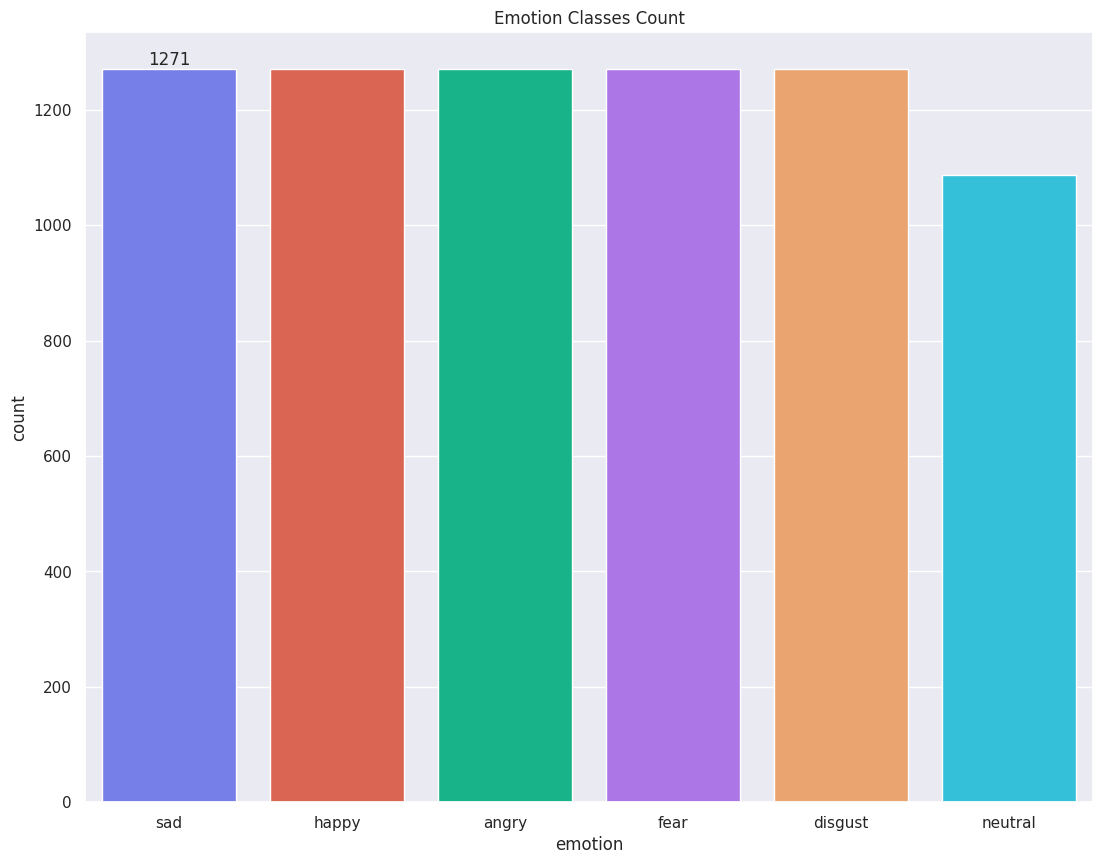

In [411]:
plt.figure(figsize = (13,10))
plt.title('Emotion Classes Count')
ax = sns.countplot(data = combined_df, x = 'emotion', order = combined_df['emotion'].value_counts().index, palette = ['#636efa', '#ef553b', '#00cc96', '#ab63fa', '#ffa15a', '#19d3f3', '#ff6692', '#b5e87f'])
ax.bar_label(ax.containers[0])

plt.show()


In [412]:
combined_df['emotion'].value_counts()

labels = combined_df['emotion'].value_counts().index
values = combined_df['emotion'].value_counts().values
colors=['#636efa', '#ef553b', '#00cc96', '#ab63fa', '#ffa15a', '#19d3f3', '#ff6692', '#b5e87f']

fig = go.Figure(data=[go.Pie(labels = labels, values = values, textinfo = 'label+percent',
                             insidetextorientation = 'radial',marker = dict(colors = colors))])

fig.update_layout(title='Emotion Classes Counts')
fig.show()


## 1.14 Bar Graph and Pie Chart of the Unique Genders


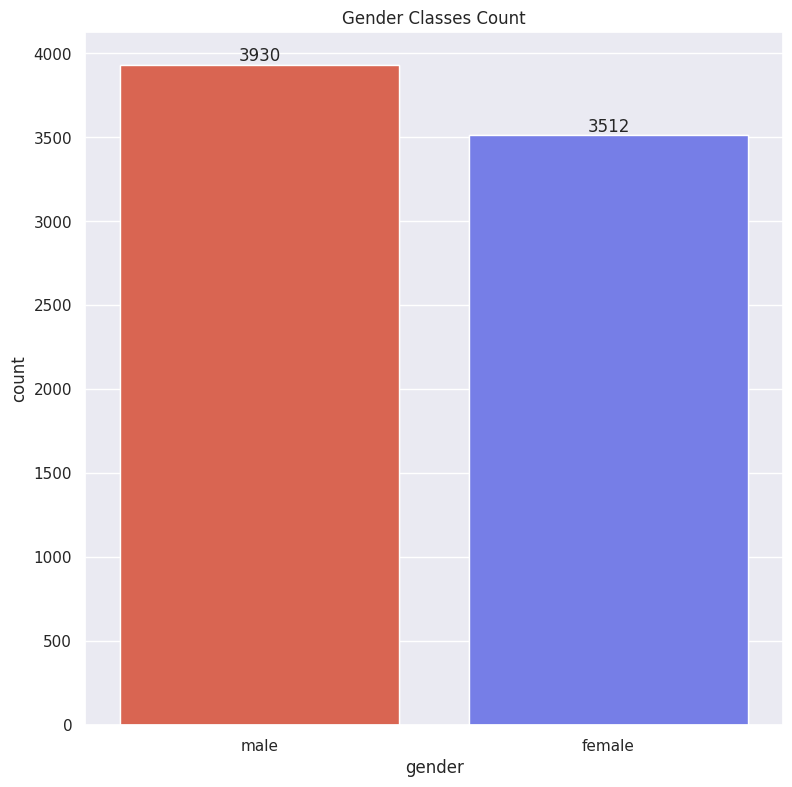

In [413]:
plt.figure(figsize = (9,9))
plt.title('Gender Classes Count')
genders = sns.countplot(x = 'gender',data = combined_df)
genders.set_xticklabels(genders.get_xticklabels())
ax = sns.countplot(x = 'gender', data = combined_df, palette = ['#ef553b', '#636efa'])
ax.bar_label(ax.containers[0])
plt.show()


In [414]:
combined_df['gender'].value_counts()

labels = combined_df['gender'].value_counts().index
values = combined_df['gender'].value_counts().values
colors = ['#ef553b', '#636efa']

fig = go.Figure(data = [go.Pie(labels = labels, values = values, textinfo = 'label+percent',
                             insidetextorientation = 'radial',marker = dict(colors = colors))])
fig.update_layout(title = 'Gender Classes Counts')
fig.show()


## 1.15 Set Color For Each Emotion


In [415]:
emotion_colors = {'surprise':'#ff6692',
                'neutral':'#19d3f3',
                'disgust':'#636efa',
                'fear':'#ef553b',
                'sad':'#ffa15a',
                'calm':'#b5e87f',
                'happy':'#00cc96',
                'angry':'#ab63fa'}


## 1.16 Wave Plot For Each Emotion


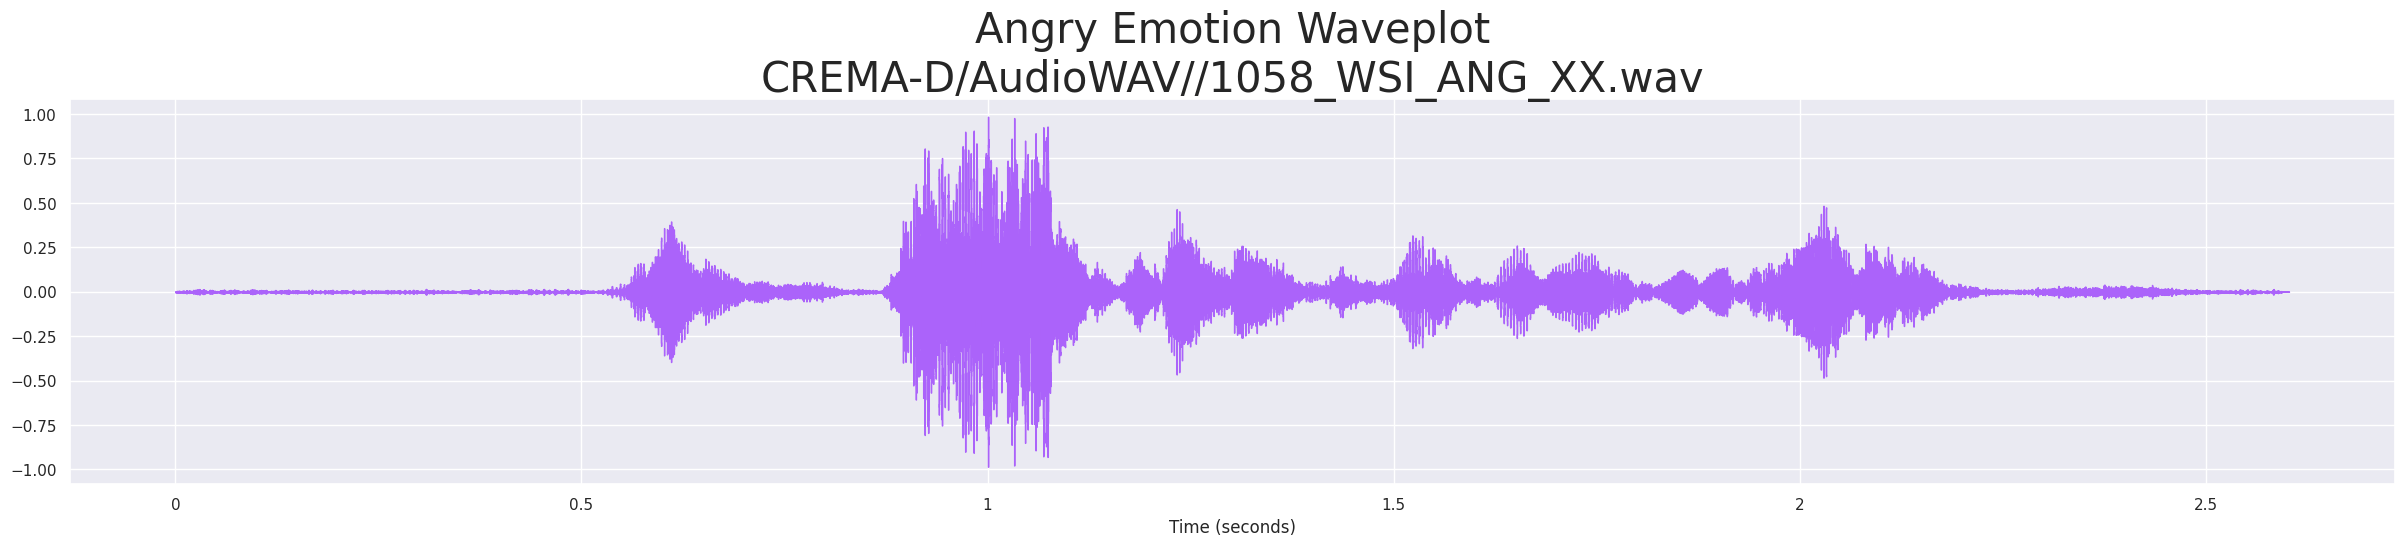

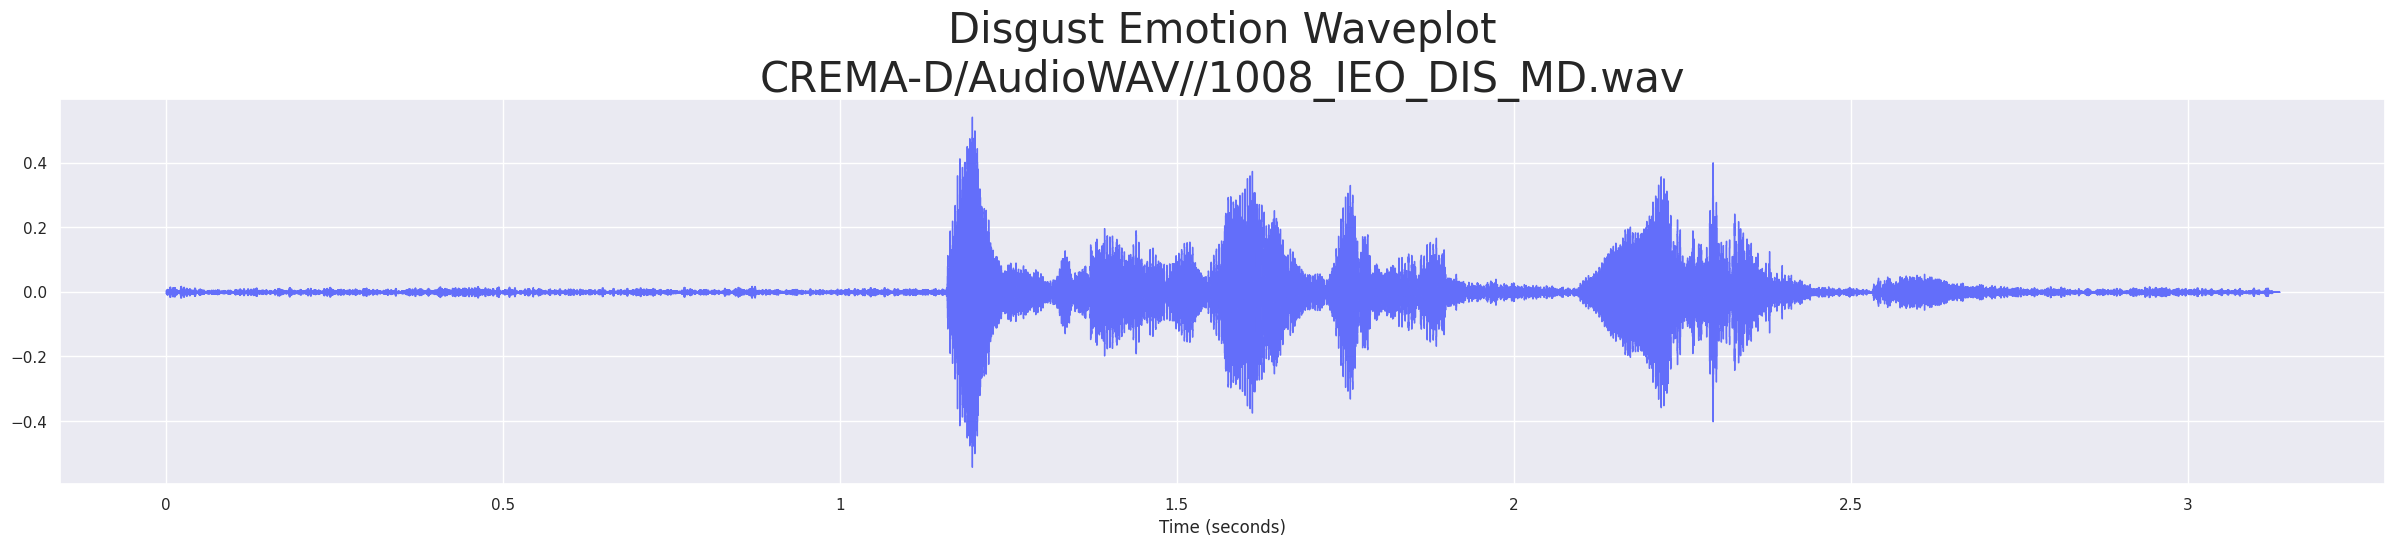

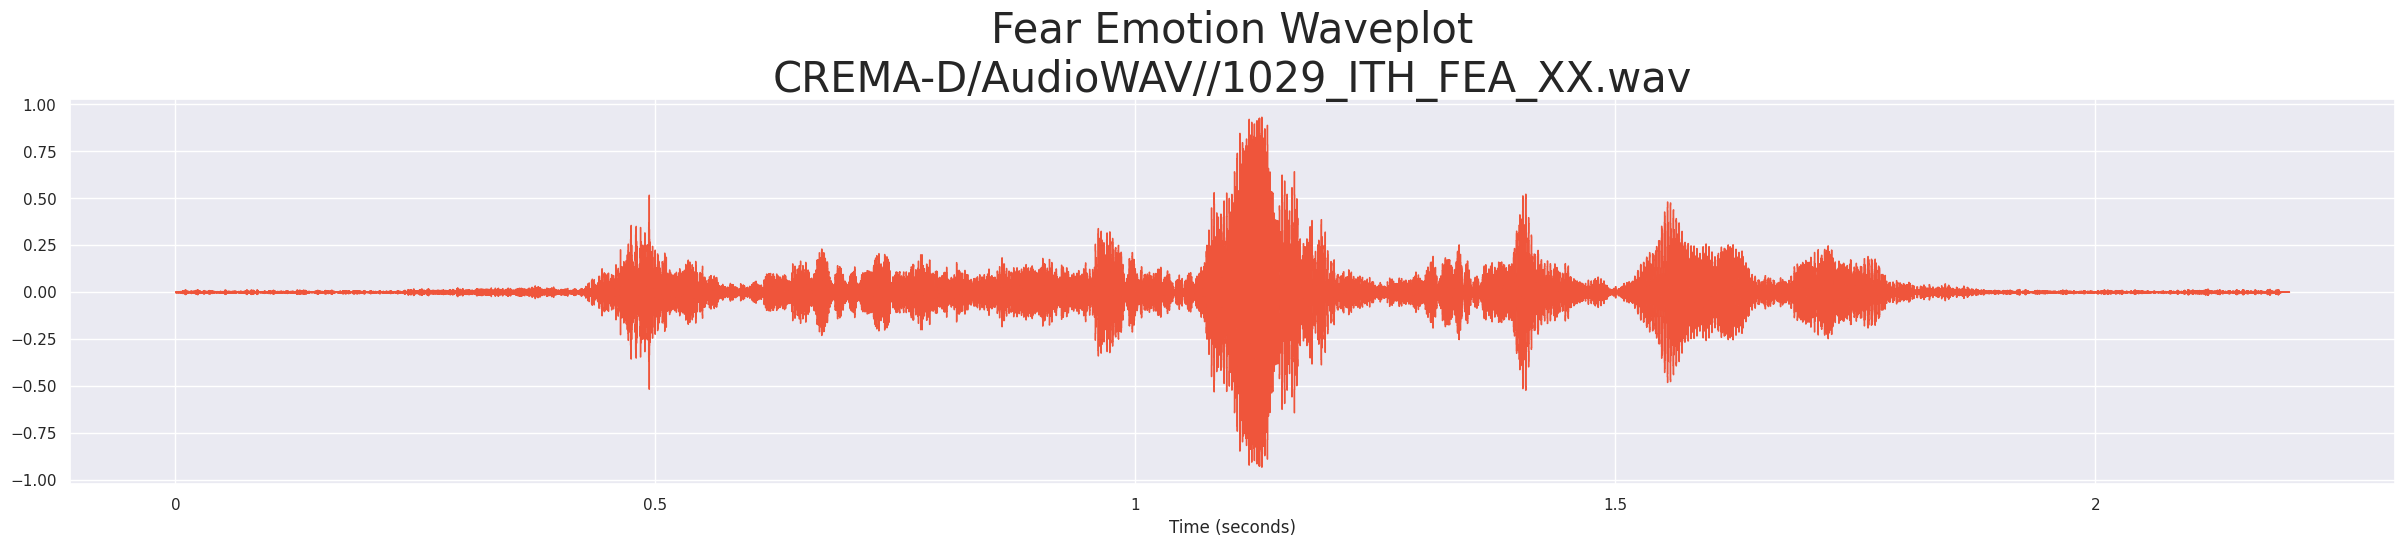

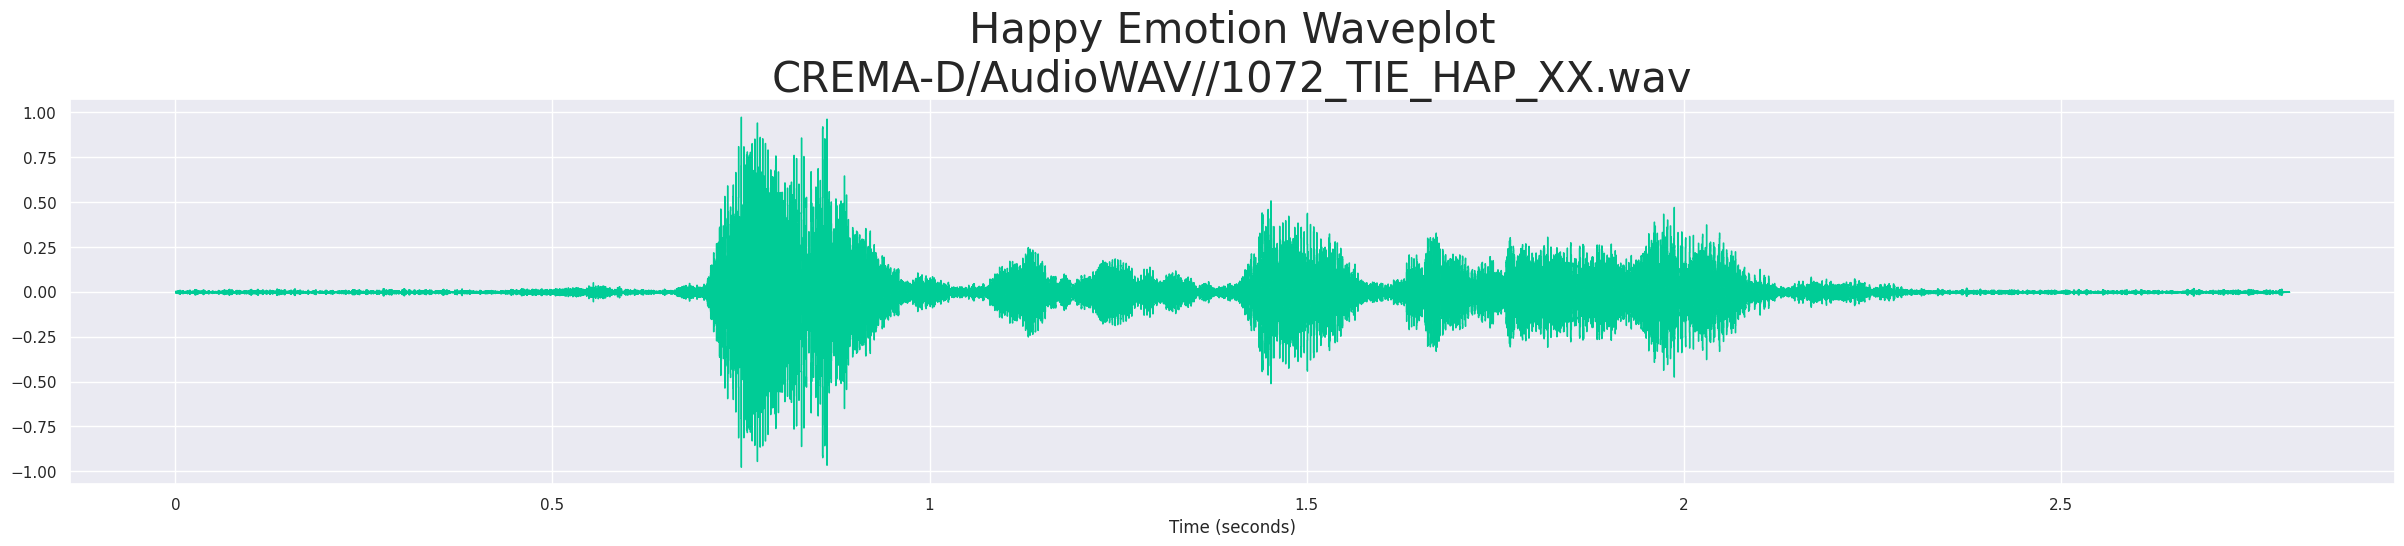

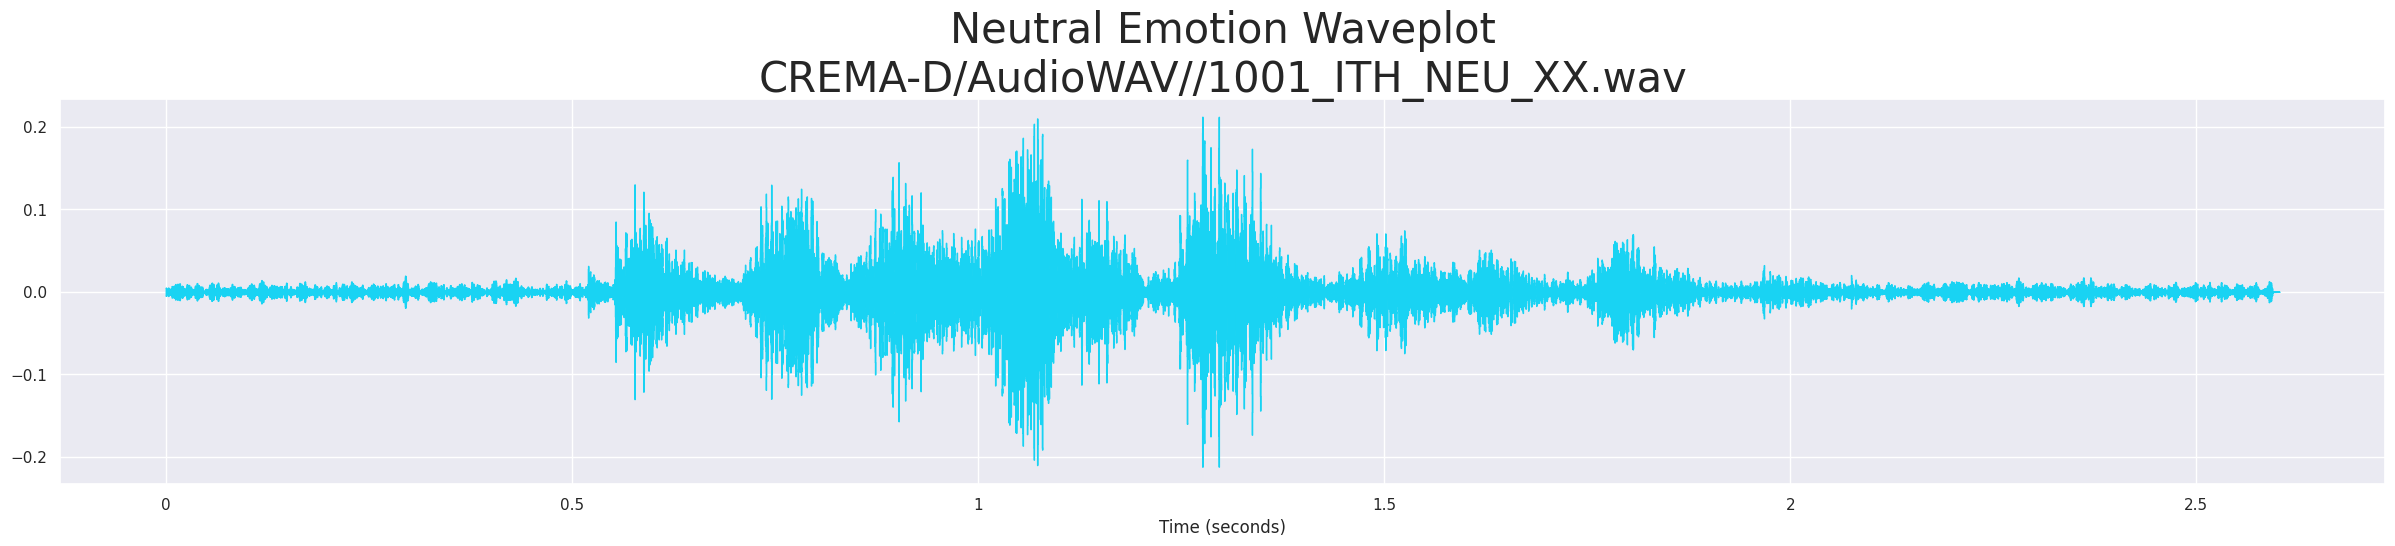

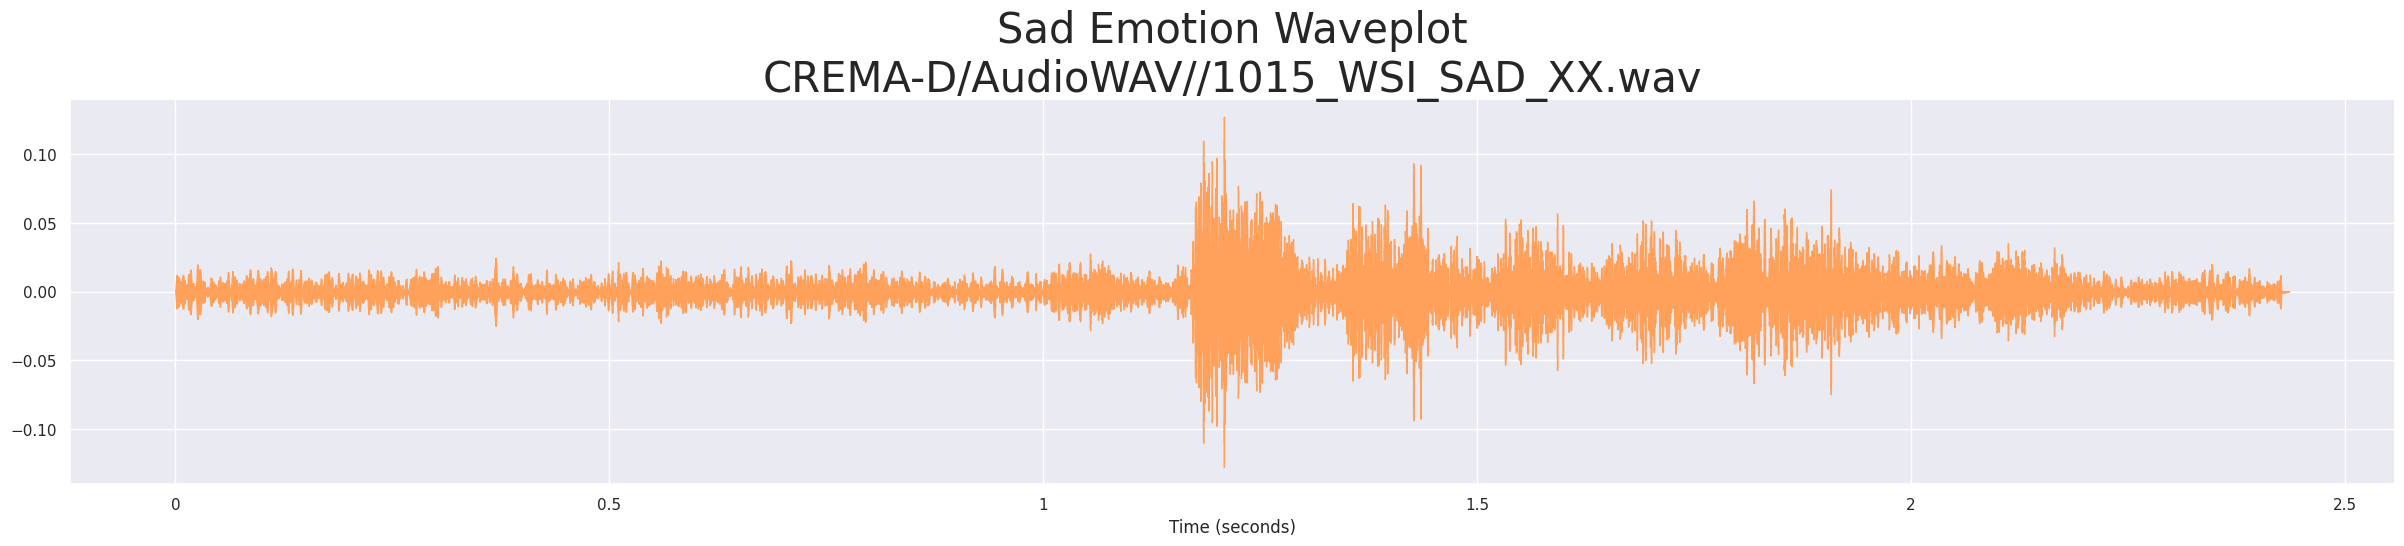

In [416]:
def wave_plot(audio_time_series, sampling_rate, emotion_class, emotion_color, file_path):
    plt.figure(figsize = (30, 5))
    librosa.display.waveshow(y = audio_time_series,sr = sampling_rate,color = emotion_color, x_axis = 's')
    plt.title(f'{emotion_class.capitalize()} Emotion Waveplot\n{file_path}', size = 30)


audio_path=[]
for emotion_class in emotions_classes:
    file_path = np.array(combined_df['location'][combined_df['emotion'] == emotion_class])[0]
    audio_time_series,sampling_rate = librosa.load(file_path)
    wave_plot(audio_time_series, sampling_rate, emotion_class, emotion_colors[emotion_class], file_path)


## 1.17 Spectogram For Each Emotion


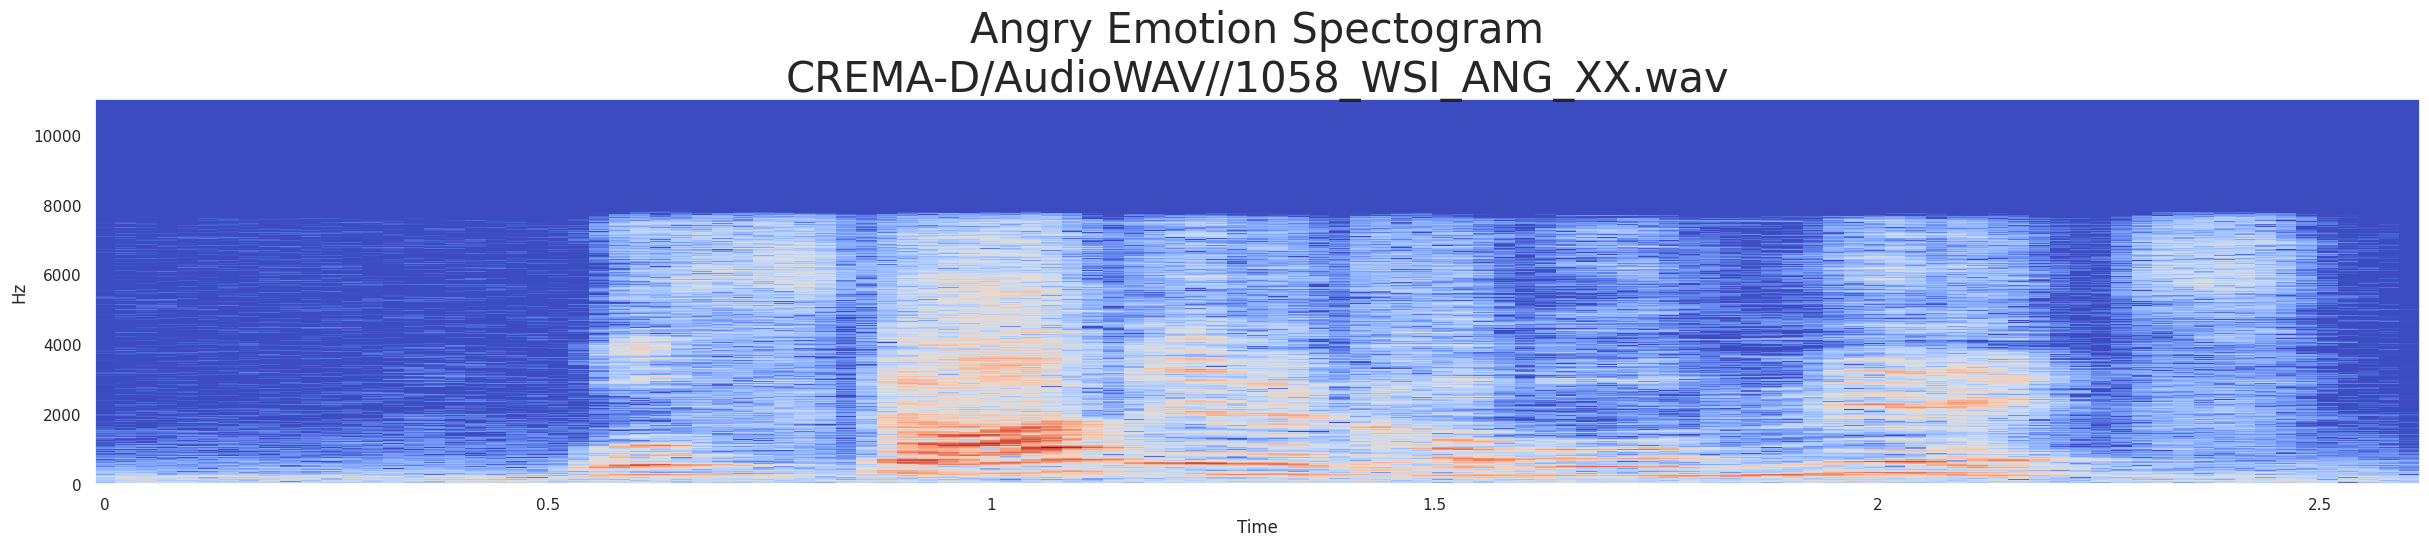

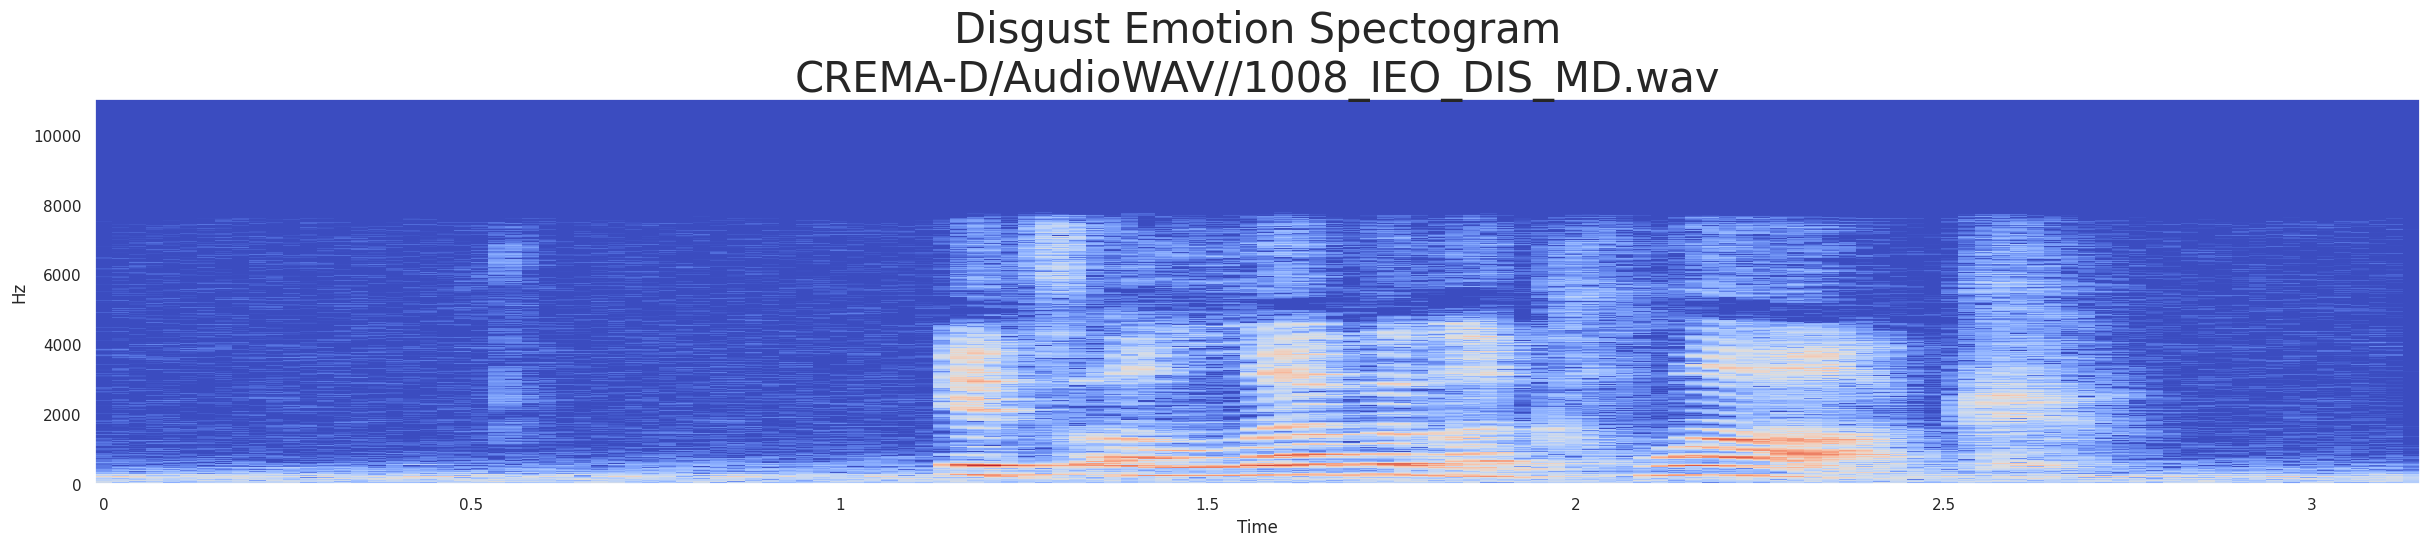

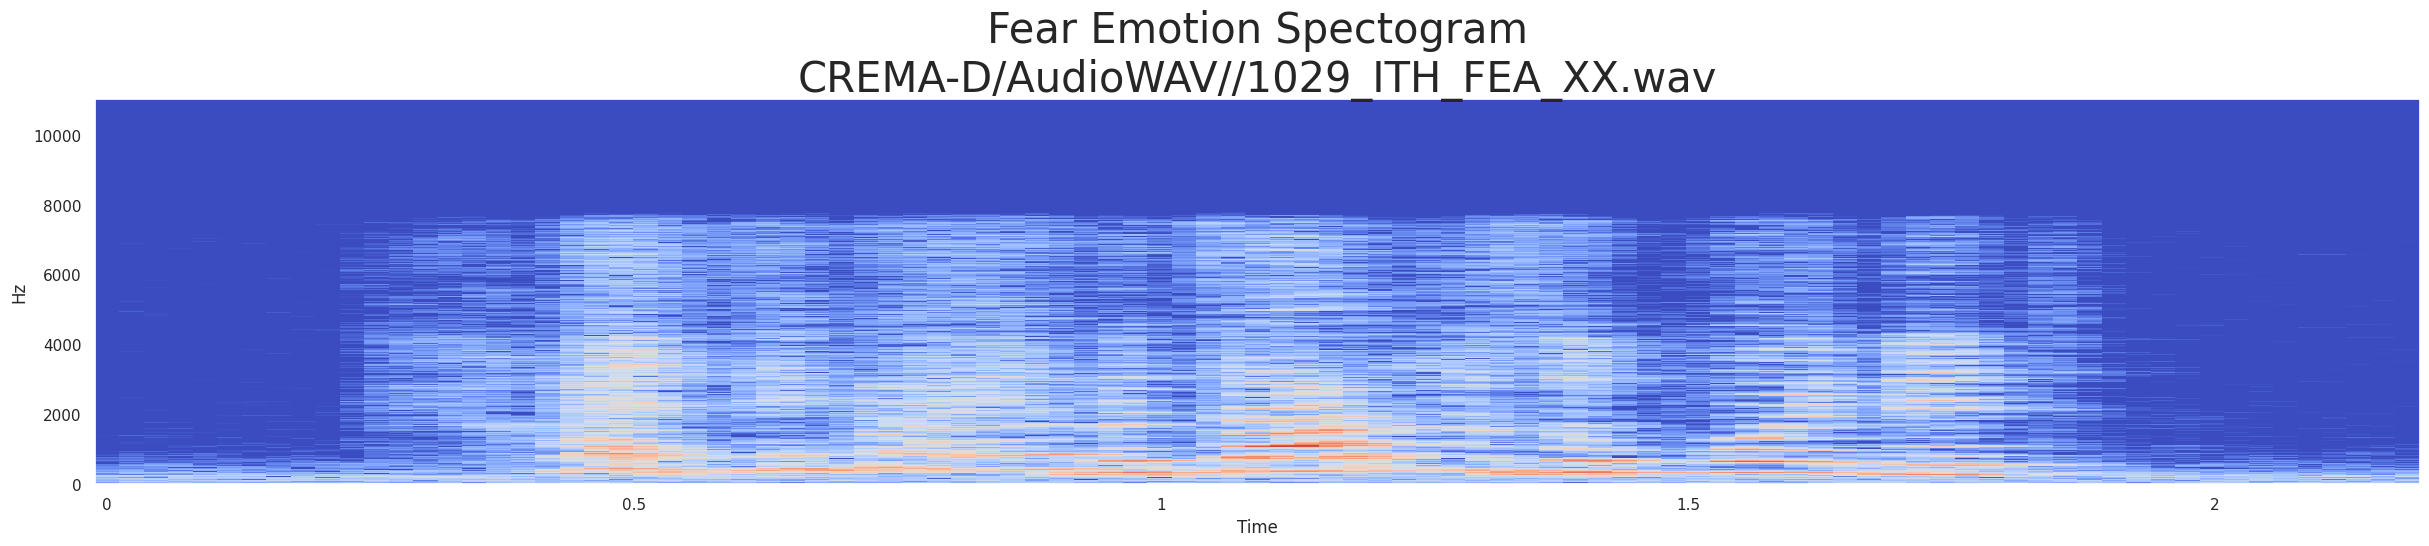

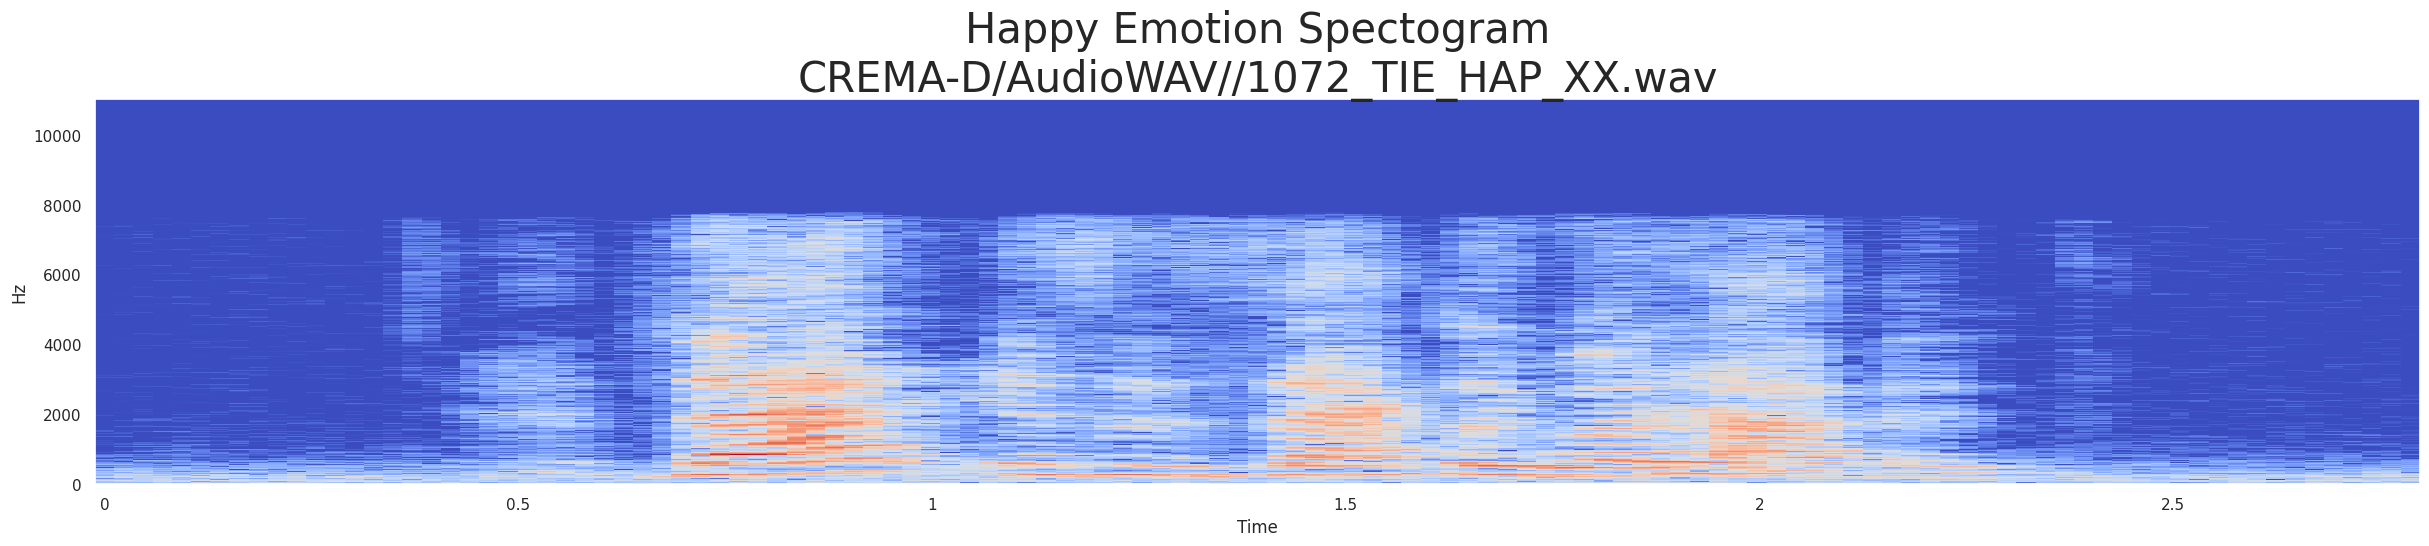

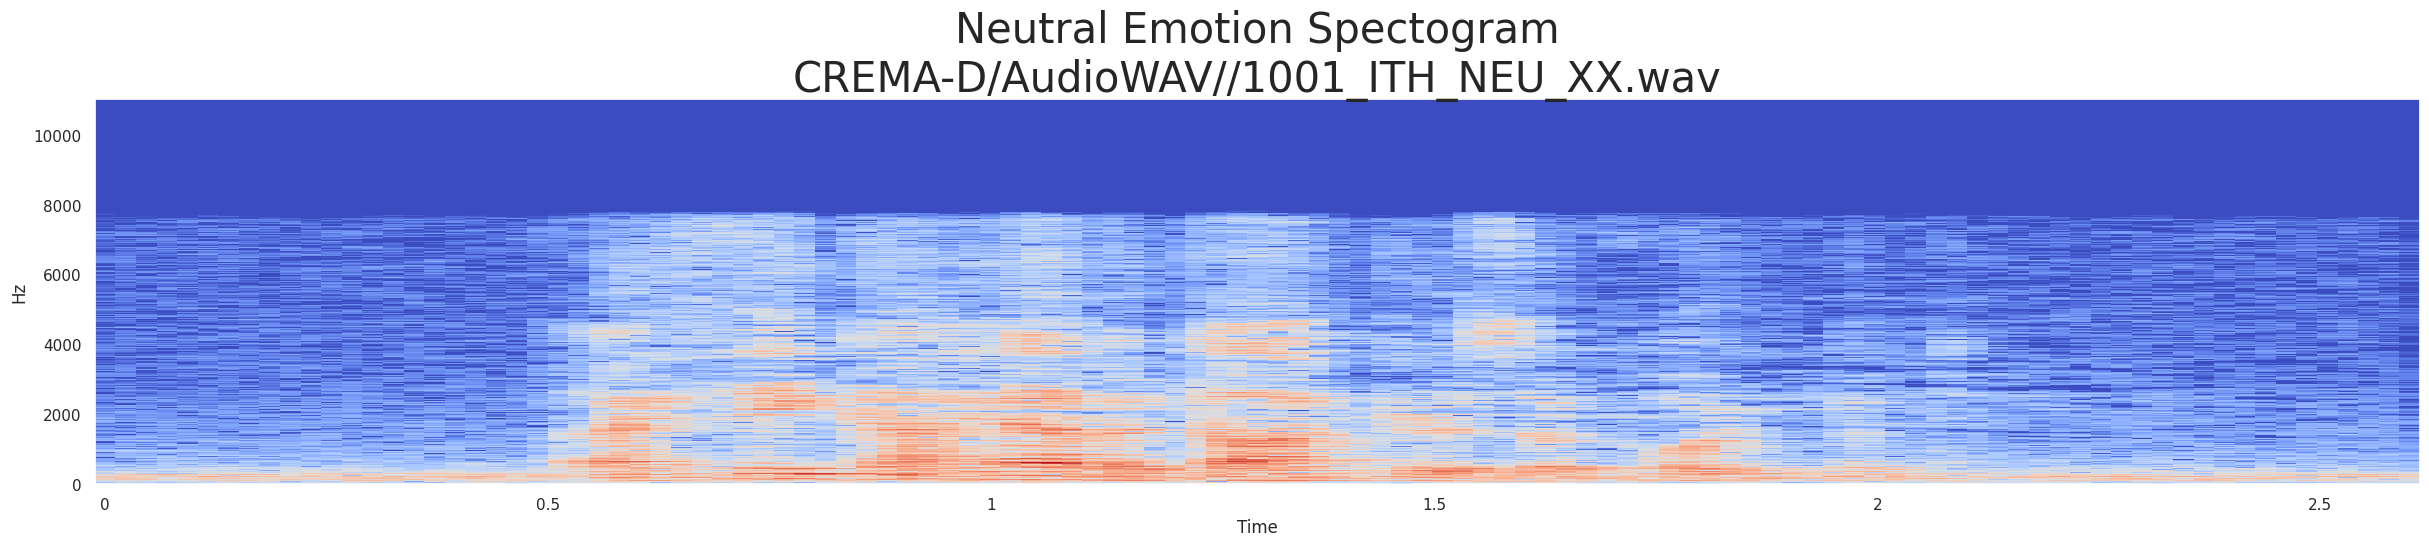

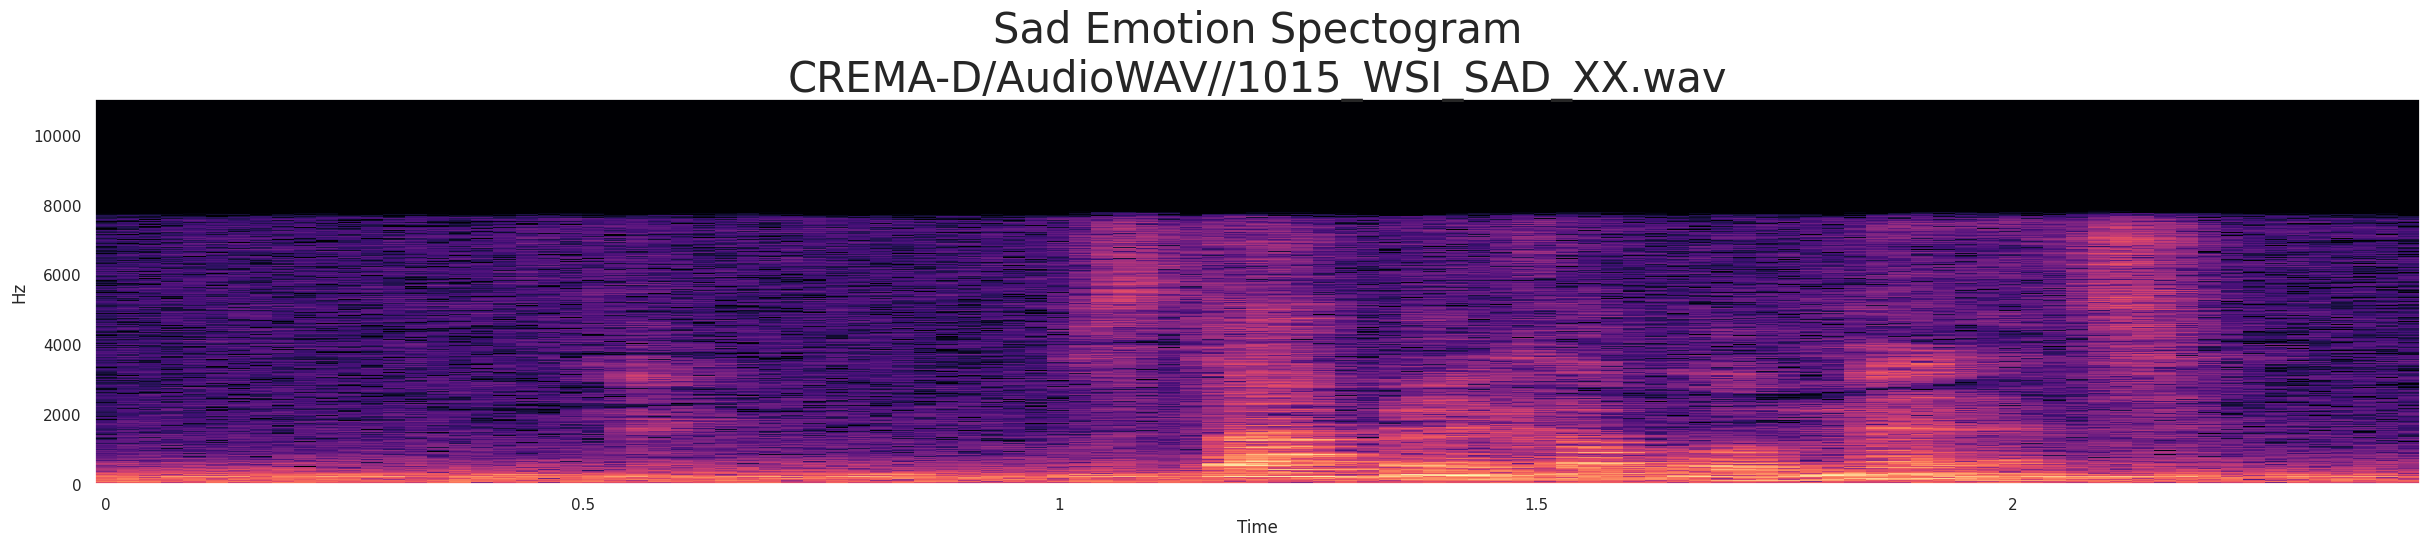

In [417]:
def spectogram(audio_time_series, sampling_rate, emotion_class, file_path):
    audio = librosa.stft(audio_time_series)
    audio_db = librosa.amplitude_to_db(abs(audio))
    plt.figure(figsize = (30,5))
    plt.title(f'{emotion_class.capitalize()} Emotion Spectogram\n{file_path}',size = 30)
    librosa.display.specshow(audio_db, sr = sampling_rate, x_axis = 'time', y_axis = 'hz')


audio_path=[]
for emotion_class in emotions_classes:
    file_path = np.array(combined_df['location'][combined_df['emotion'] == emotion_class])[0]
    audio_time_series, sampling_rate = librosa.load(file_path)
    spectogram(audio_time_series, sampling_rate, emotion_class, file_path)


## 1.18 Mel Spectogram For Each Emotion


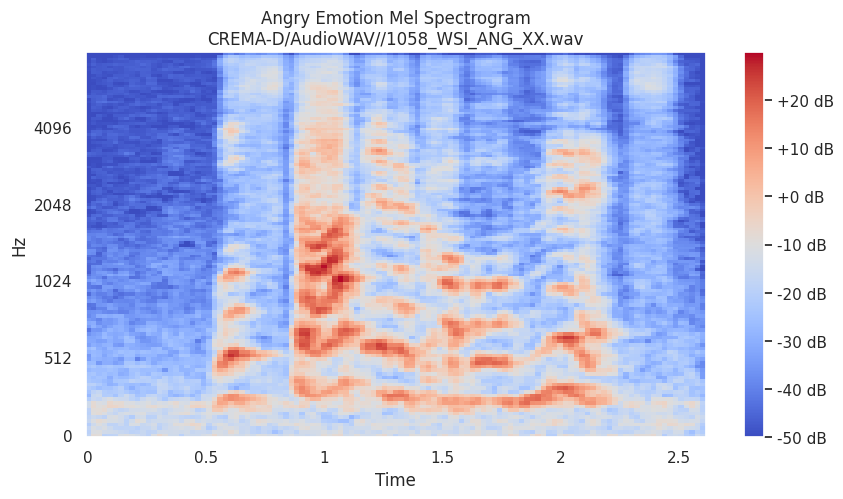

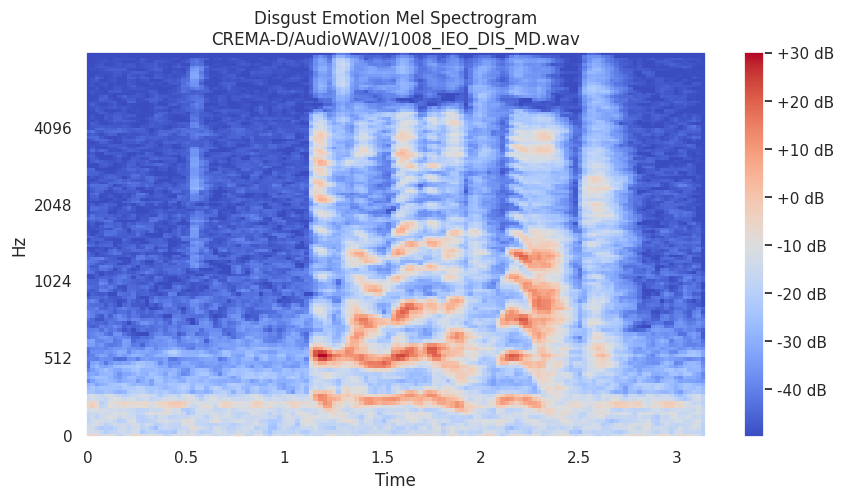

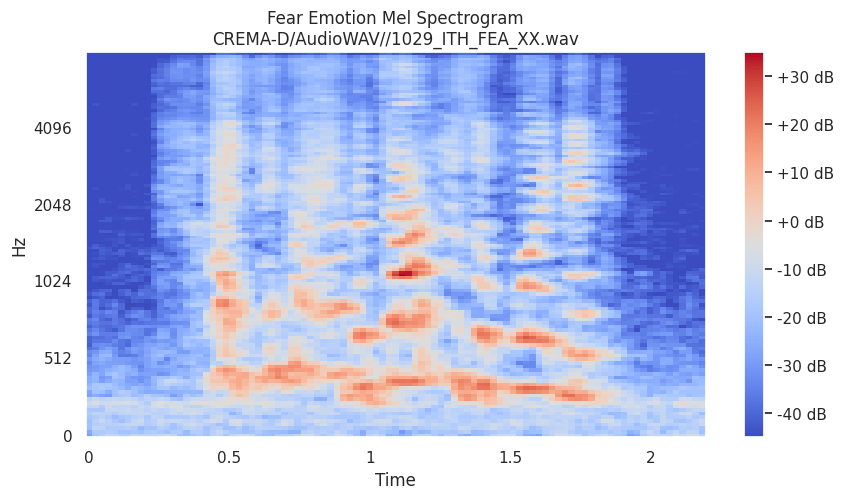

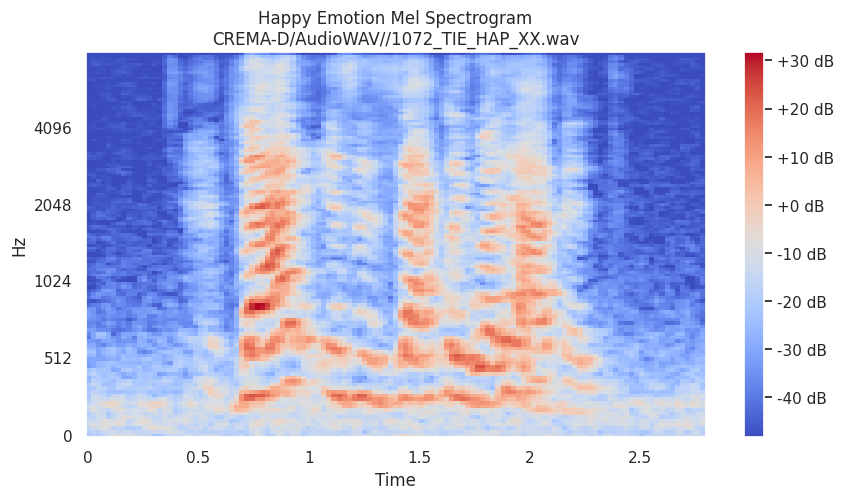

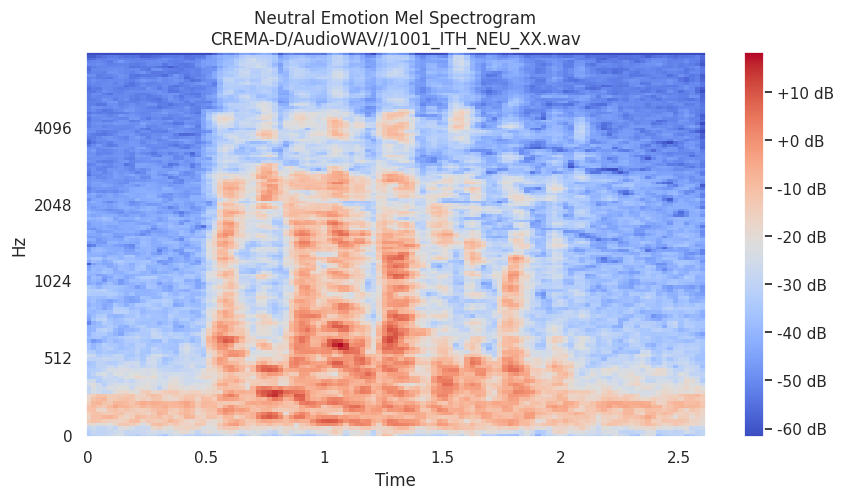

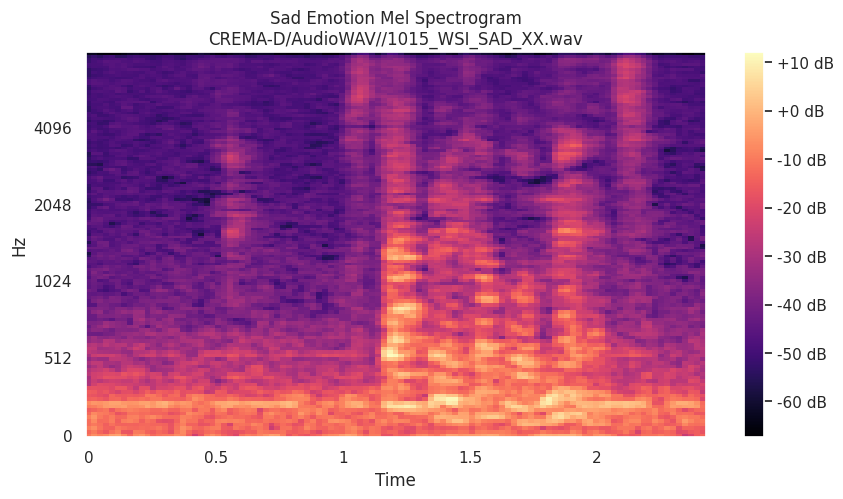

In [418]:
def mel_spectogram(audio_time_series, sampling_rate, emotion_class, file_path):
    spectrogram = librosa.feature.melspectrogram(y = audio_time_series, sr = sampling_rate, n_mels = 128,fmax = 8000) 
    spectrogram = librosa.power_to_db(spectrogram)
    plt.figure(figsize = (10, 5))
    plt.title(f'{emotion_class.capitalize()} Emotion Mel Spectrogram\n{file_path}')
    librosa.display.specshow(spectrogram, fmax = 8000, x_axis = 'time',y_axis = 'mel')
    plt.colorbar(format = '%+2.0f dB')


audio_path = []
for emotion_class in emotions_classes:
    file_path = np.array(combined_df['location'][combined_df['emotion'] == emotion_class])[0]
    audio_time_series, sampling_rate = librosa.load(file_path)
    mel_spectogram(audio_time_series, sampling_rate, emotion_class, file_path)
    audio_path.append(file_path)


## 1.19 Play the Sound File For Each of the Emotions Above to Make Sure Sound Files are Valid and Match the Waveform, Spectogram, and Mel Spectrogram Above.


In [419]:
print('emotions_classes =', emotions_classes,'\n')

for i in range(len(emotions_classes) - 1):
        print(emotions_classes[i].capitalize(), 'Audio Sample\n')
        print(audio_path[i])
        IPython.display.display(IPython.display.Audio(data = audio_path[i]))


emotions_classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad'] 

Angry Audio Sample

CREMA-D/AudioWAV//1058_WSI_ANG_XX.wav


Disgust Audio Sample

CREMA-D/AudioWAV//1008_IEO_DIS_MD.wav


Fear Audio Sample

CREMA-D/AudioWAV//1029_ITH_FEA_XX.wav


Happy Audio Sample

CREMA-D/AudioWAV//1072_TIE_HAP_XX.wav


Neutral Audio Sample

CREMA-D/AudioWAV//1001_ITH_NEU_XX.wav


___
## #2 Select and Engineer Features


## 2.1 Audio Data Augmentation
> 1. Noise Injection
> 2. Pitching
> 3. Stretching


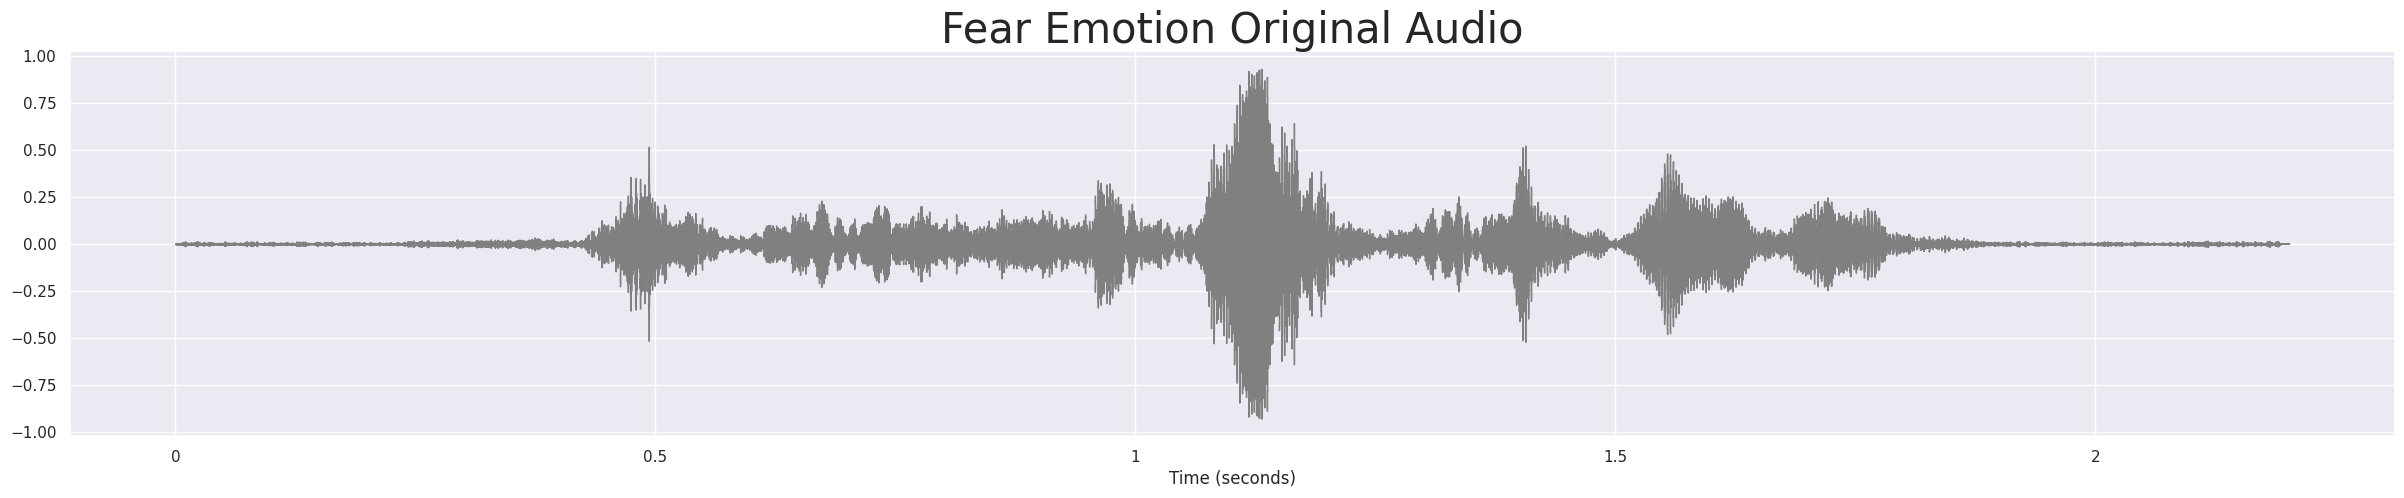

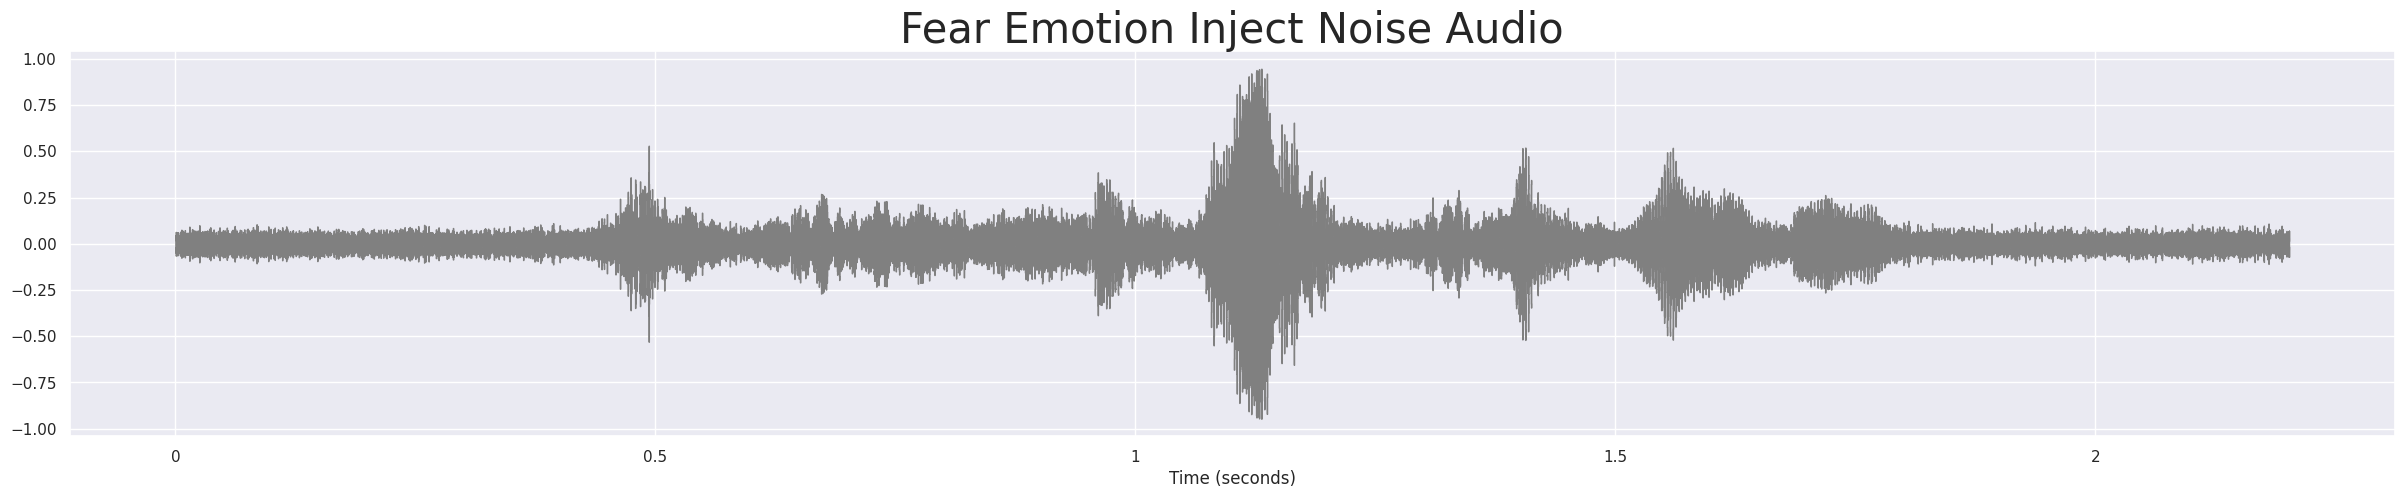

In [420]:
# Noise Injection.
def inject_noise(data, sampling_rate = 0.035, threshold = 0.075, random = False):
    if random:
        sampling_rate = np.random.random() * threshold
    noise_amplitude = sampling_rate * np.random.uniform() * np.amax(data)
    augmented_data = data + noise_amplitude * np.random.normal(size = data.shape[0])
    return augmented_data


# Test audio file (fear emotion).
data, sampling_rate = librosa.load(path = audio_path[2])

IPython.display.display(IPython.display.Audio(data = audio_path[2]))

plt.figure(figsize = (30,5))
librosa.display.waveshow(y = data, sr = sampling_rate, color = '#808080', x_axis = 's')
plt.title('Fear Emotion Original Audio', size = 30)

noise_audio = inject_noise(data)
plt.figure(figsize = (30,5))
librosa.display.waveshow(y = noise_audio, sr = sampling_rate, color = '#808080', x_axis = 's')
plt.title('Fear Emotion Inject Noise Audio', size = 30)
plt.show()
IPython.display.display(IPython.display.Audio(data = noise_audio, rate = sampling_rate))


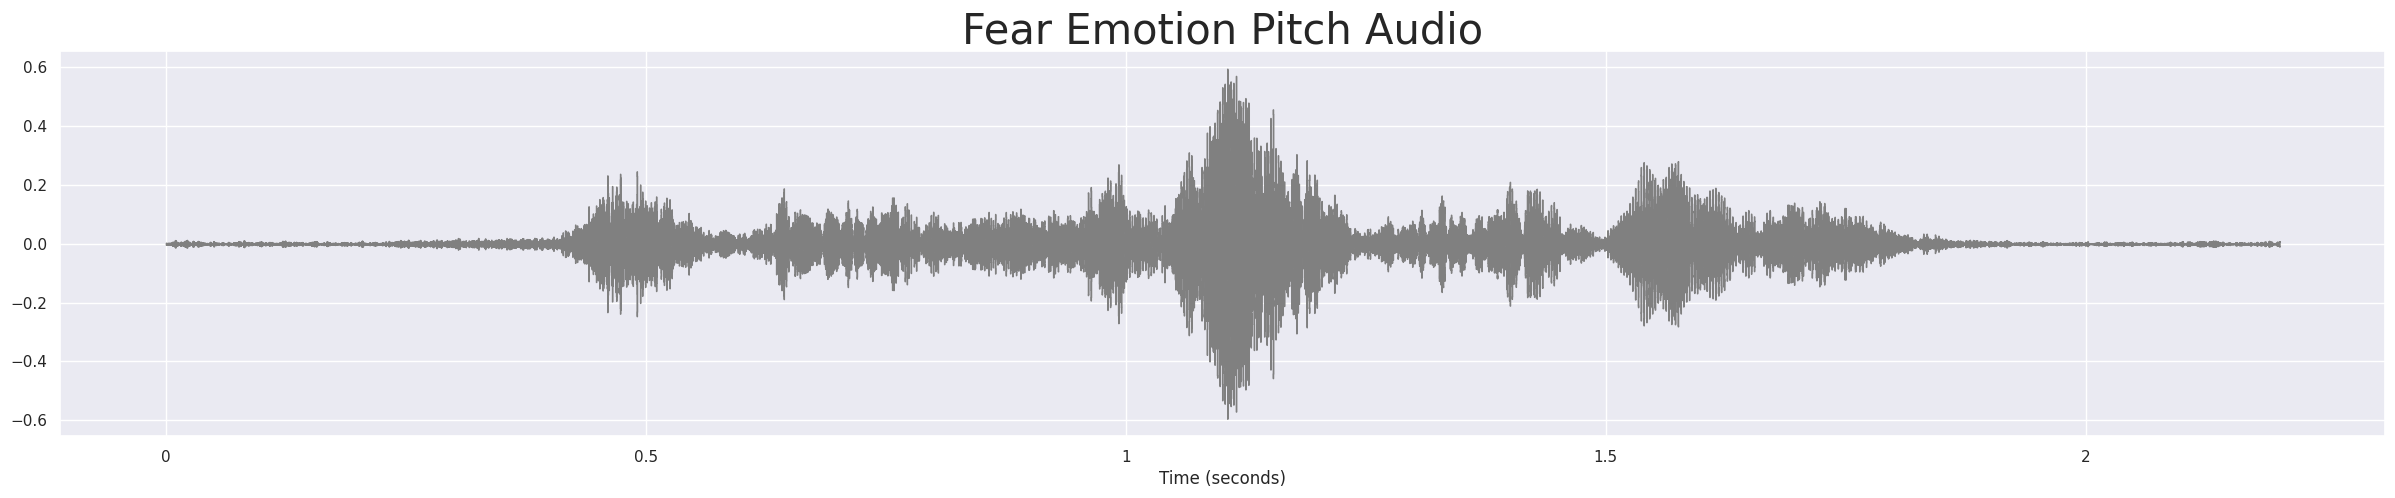

In [421]:
# Pitching.
def pitching(data, sampling_rate, pitch_factor = 0.7,random = False):
    if random:
        pitch_factor= np.random.random() * pitch_factor
    return librosa.effects.pitch_shift(y = data, sr = sampling_rate, n_steps = pitch_factor)


# Test audio file (fear emotion).
pitch_audio = pitching(data, sampling_rate)
plt.figure(figsize = (30,5))
librosa.display.waveshow(y = pitch_audio, sr = sampling_rate, color = '#808080', x_axis = 's')
plt.title('Fear Emotion Pitch Audio', size = 30)
plt.show()
IPython.display.display(IPython.display.Audio(data = pitch_audio, rate = sampling_rate))


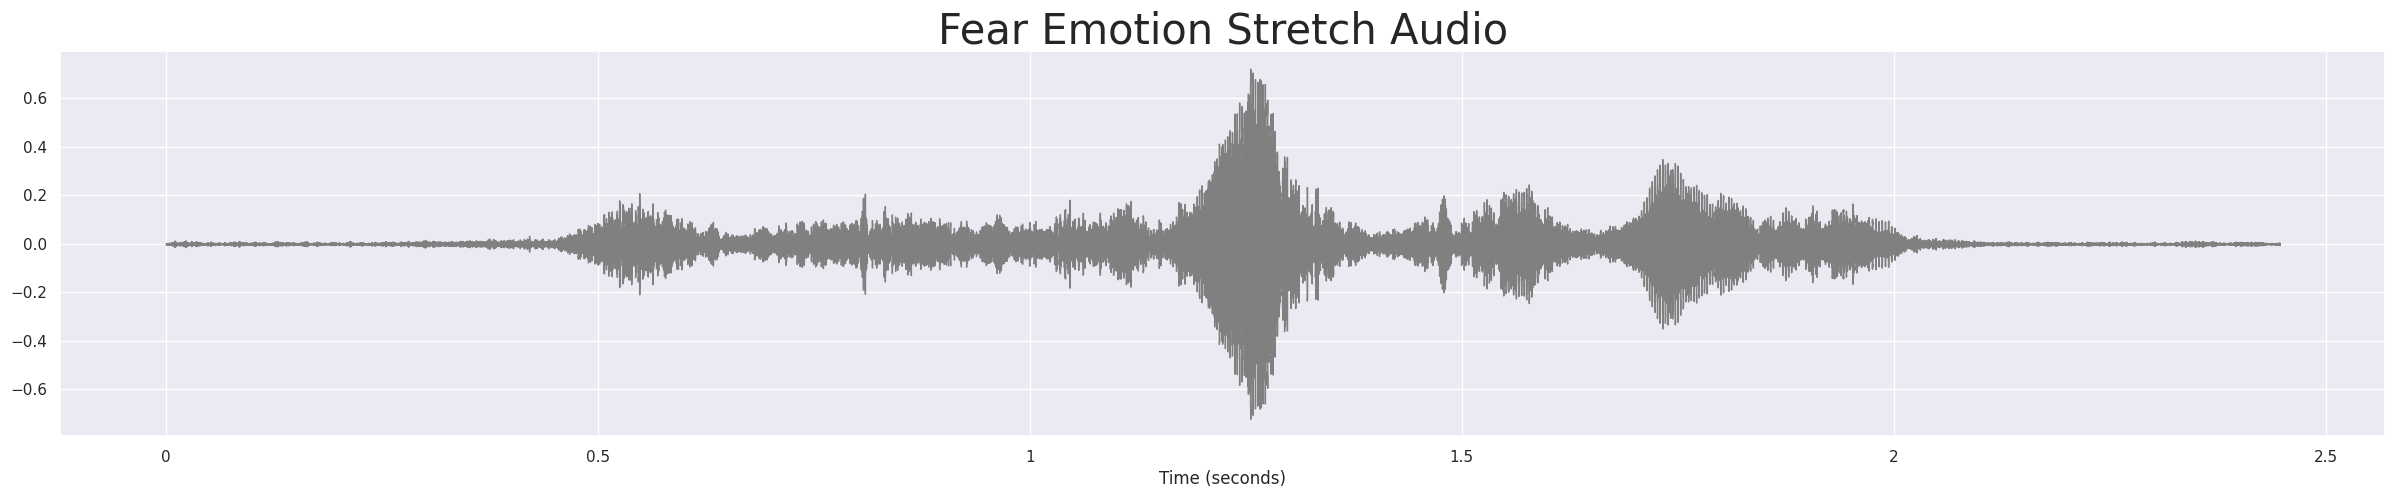

In [422]:
# Stretching.
def stretching(data,r = 0.9):
    return librosa.effects.time_stretch(y = data, rate = r)


# Test audio file (fear emotion).
stretch_audio = stretching(data)
plt.figure(figsize = (30,5))
librosa.display.waveshow(y = stretch_audio, sr = sampling_rate, color = '#808080', x_axis = 's')
plt.title('Fear Emotion Stretch Audio', size = 30)
plt.show()
IPython.display.display(IPython.display.Audio(data = stretch_audio, rate = sampling_rate))


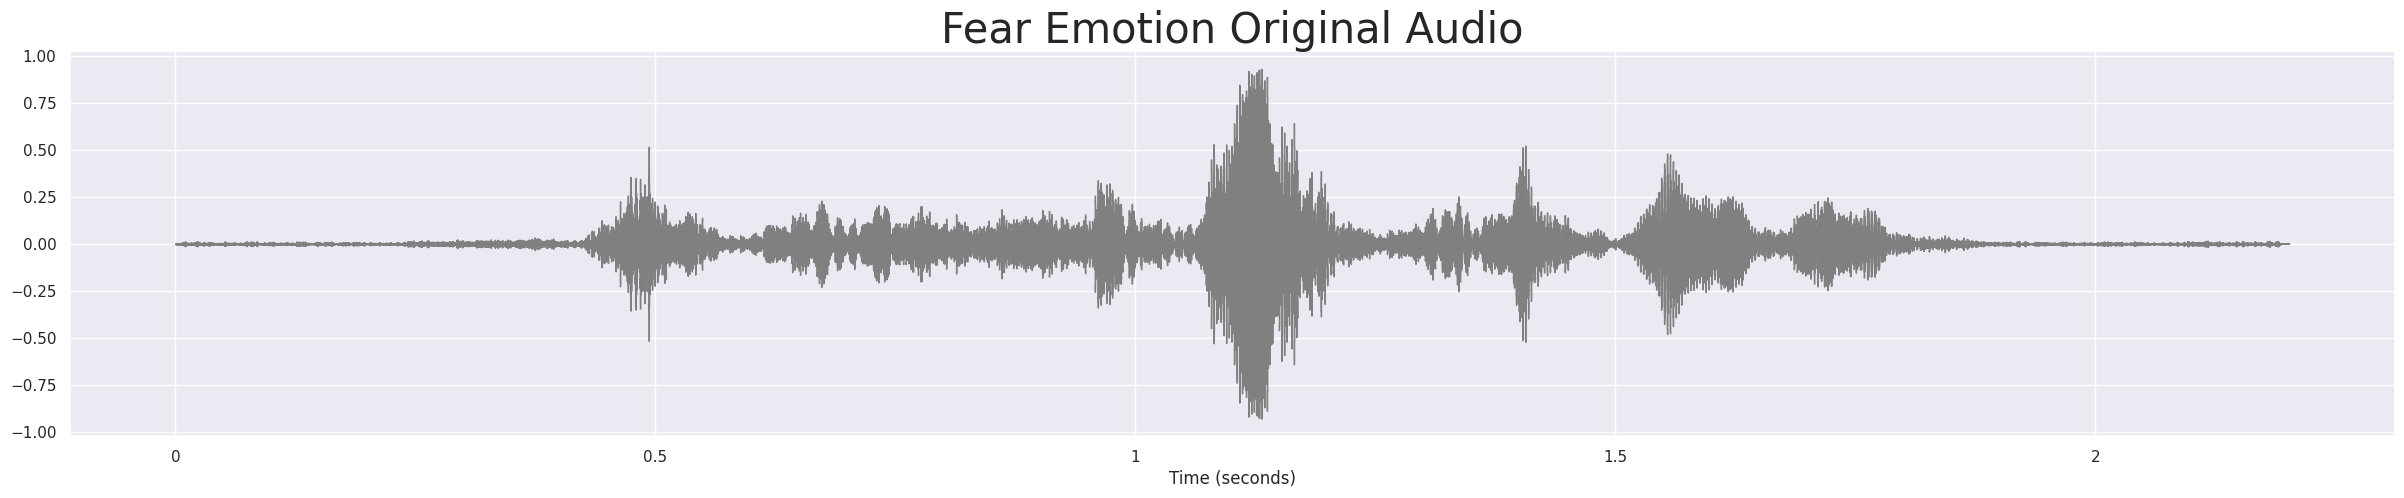

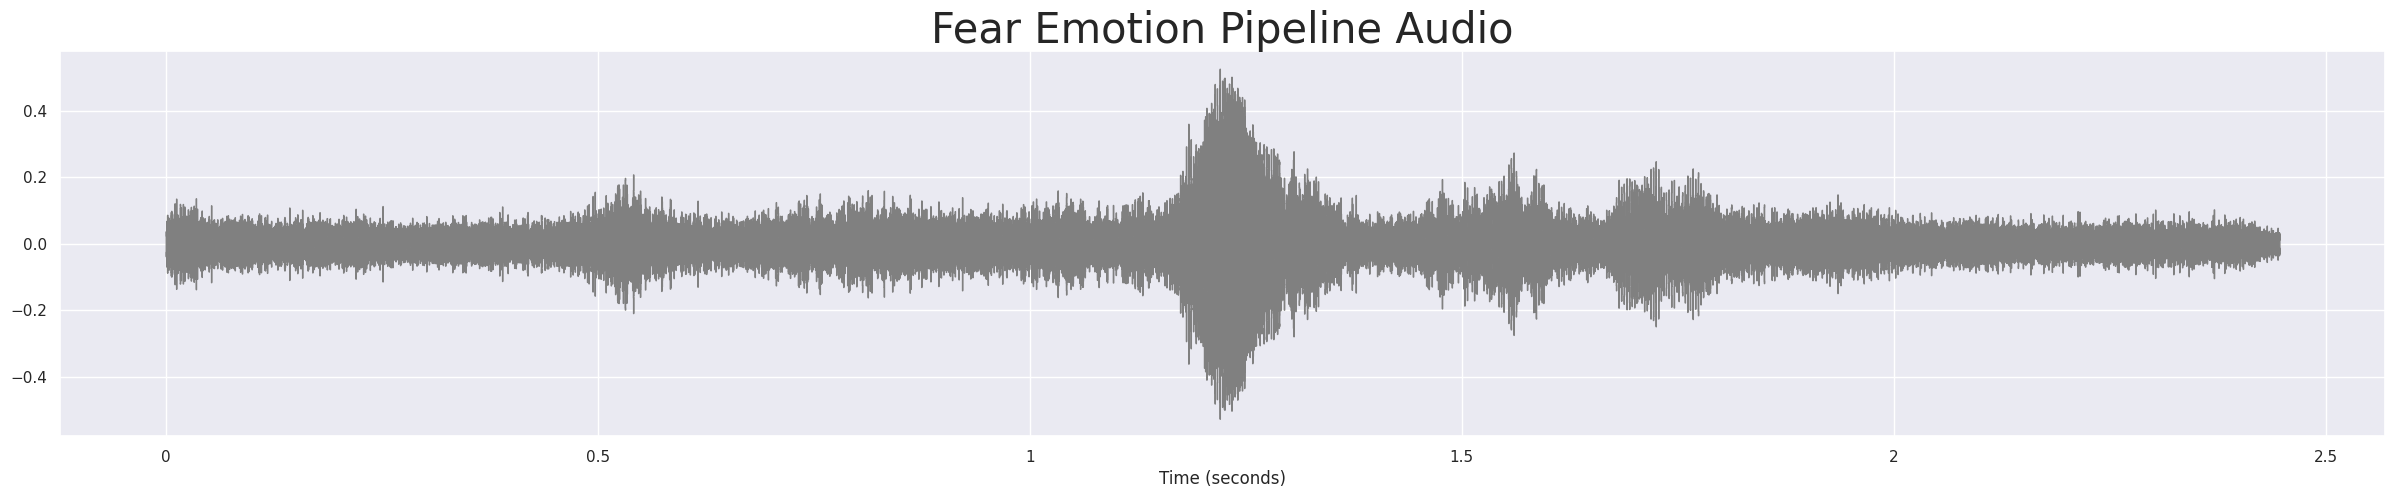

In [423]:
# Pipeline function that applies all the audio data augmentation functions we just built.
def pipeline(data, sampling_rate):
    data = pitching(data, sampling_rate, random = True)
    data = inject_noise(data, random = True)
    data = stretching(data)
    return data


# Test audio file (fear emotion).
data, sampling_rate = librosa.load(path = audio_path[2])

IPython.display.display(IPython.display.Audio(data = audio_path[2]))

plt.figure(figsize = (30,5))
librosa.display.waveshow(y = data, sr = sampling_rate, color = '#808080', x_axis = 's')
plt.title('Fear Emotion Original Audio', size = 30)

pipeline_audio = pipeline(data, sampling_rate)
plt.figure(figsize = (30,5))
librosa.display.waveshow(y = pipeline_audio, sr = sampling_rate, color = '#808080', x_axis = 's')
plt.title('Fear Emotion Pipeline Audio', size = 30)
plt.show()
IPython.display.display(IPython.display.Audio(data = pipeline_audio, rate = sampling_rate))


## 2.2 Audio Data Feature Extraction
> 1. **Zero Crossing Rate:** The rate of sign-changes of the signal during the duration of a particular frame.
> 2. **Root Mean Square:**  Metering tool that measures the average loudness of an audio track within a window of roughly 300 milliseconds.
> 3. **Mel Frequency Cepstral Coefficients:** Form a cepstral representation where the frequency bands are not linear but distributed according to the mel-scale.
> 4. **Chromagram:** Represents the 12 different pitches under an audio file, in one place so that we can understand the classification of the pitches in the audio files.
> 5. **Melspectrogram:** Scale of pitches that can be felt by the listener to be equal in distance from one another.
> 6. **Spectral Centroid:** The center of gravity of the spectrum.
> 7. **Spectral Bandwidth:** The difference between the upper and lower frequencies in a continuous band of frequencies.
> 8. **Spectral Rolloff:** The frequency below which 90% of the magnitude distribution of the spectrum is concentrated.
> 9. **Spectral Entropy:** Entropy of the normalized spectral energies for a set of sub-frames.
> 10. **Spectral Flux:** The squared difference between the normalized magnitudes of the spectra of the two successive frames.

***NOTE: Due to memory limitation, we will only do Mel Frequency Cepstral Coefficients, Root Mean Square, and Zero Crossing Rate.***


In [424]:
def zero_crossing_rate(data, frame_length, hop_length):
    zcr = librosa.feature.zero_crossing_rate(y = data, frame_length = frame_length, hop_length = hop_length)
    return np.squeeze(zcr)

def root_mean_square(data, frame_length = 2048, hop_length = 512):
    rms = librosa.feature.rms(y = data, frame_length = frame_length, hop_length = hop_length)
    return np.squeeze(rms)


def mel_frequency_cepstral_coefficients(data, sampling_rate, frame_length = 2048, hop_length = 512, flatten:bool = True):
    mfcc = librosa.feature.mfcc(y = data,sr = sampling_rate)
    return np.squeeze(mfcc.T) if not flatten else np.ravel(mfcc.T)


def chroma_stft(data, sampling_rate, frame_length = 2048, hop_length = 512, flatten: bool = True):
    short_time_fourier_transform = np.abs(librosa.stft(data))
    chroma = librosa.feature.chroma_stft(sr = sampling_rate, S = short_time_fourier_transform)
    return np.squeeze(chroma.T) if not flatten else np.ravel(chroma.T)


def melspectrogram(data, sampling_rate, frame_length = 2048, hop_length = 512, flatten: bool = True):
    melspect = librosa.feature.melspectrogram(y = data, sr = sampling_rate)
    return np.squeeze(melspect.T) if not flatten else np.ravel(melspect.T)


def spectral_centroid(data, sampling_rate, frame_length = 2048, hop_length = 512):
    scentroid = librosa.feature.spectral_centroid(y = data, sr = sampling_rate, n_fft = frame_length, hop_length = hop_length)
    return np.squeeze(scentroid)


def spectral_bandwidth(data, sampling_rate, frame_length = 2048, hop_length = 512):
    sbandwidth = librosa.feature.spectral_bandwidth(y = data, sr = sampling_rate, n_fft = frame_length, hop_length = hop_length)
    return np.squeeze(sbandwidth)


def spectral_rolloff(data, sampling_rate, frame_length = 2048, hop_length = 512):
    srolloff = librosa.feature.spectral_rolloff(y = data, sr = sampling_rate, n_fft = frame_length, hop_length = hop_length)
    return np.squeeze(srolloff)


def spectral_entropyy(data, sampling_rate):
    sentropy = spectral_entropy(x = data, sf = sampling_rate)
    return np.squeeze(sentropy)


def spectral_flux(data, sampling_rate):
    sflux = librosa.onset.onset_strength(y = data, sr = sampling_rate)
    return np.squeeze(sflux)



In [425]:
def feature_extraction(data, sampling_rate, frame_length = 2048, hop_length = 512):
    result = np.array([])
    result = np.hstack((result,
                        zero_crossing_rate(data, frame_length, hop_length),
                        root_mean_square(data, frame_length, hop_length),
                        mel_frequency_cepstral_coefficients(data, sampling_rate, frame_length, hop_length),
#                         chroma_stft(data, sampling_rate, frame_length, hop_length),
#                         melspectrogram(data, sampling_rate, frame_length, hop_length),
#                         spectral_centroid(data, sampling_rate, frame_length, hop_length),
#                         spectral_bandwidth(data, sampling_rate, frame_length, hop_length),
#                         spectral_rolloff(data, sampling_rate, frame_length, hop_length),
#                         spectral_entropyy(data, sampling_rate),
#                         spectral_flux(data, sampling_rate)
                     ))
    return result


### Four Times More Rows Than The Original/Initial Dataset Because For Each Audio File We Now Have Four Rows Representing:
> 1. No Audio Data Augmentation             (first row)
> 2. Inject Noise                           (second row)
> 3. Pitching                               (third row)
> 4. Stretching                             (fourth row)
> 5. Pitching and Inject Noise              (fifth row)
> 6. Stretching and Pitching                (sixth row)
> 7. Pitching, Inject Noise, and Stretching (seventh row)

***NOTE: Due to memory limitation, we will only do No Audio Data Augmentation, Inject Noise, Pitching, and  Pitching and Inject Noise.***


In [426]:
# Duration and offset act as placeholders because there is no audio in start and the ending of each audio file is noramlly below three seconds.
def get_features(file_path, duration = 2.5, offset = 0.6):
    data, sampling_rate = librosa.load(path = file_path, duration = duration, offset = offset)
    
    # No audio data augmentation.
    audio_1 = feature_extraction(data, sampling_rate)
#     audio_1.resize((1, 19921))
    audio = np.array(audio_1)

    # Inject Noise.
    noise_audio_1 = inject_noise(data, random = True)
    audio_2 =  feature_extraction(noise_audio_1, sampling_rate)
#     audio_2.resize((1, 19921))
    audio = np.vstack((audio, audio_2))
    
    # Pitching.
    pitch_audio_1 = pitching(data, sampling_rate, random = True)
    audio_3 = feature_extraction(pitch_audio_1, sampling_rate)
#     audio_3.resize((1, 19921))
    audio = np.vstack((audio, audio_3))
    
#     # Stretching.
#     stretch_audio_1 = stretching(data)
#     audio_4 = feature_extraction(stretch_audio_1, sampling_rate)
#     audio_4.resize((1, 19921))
#     audio = np.vstack((audio, audio_4))
    
    # Pitching and Inject Noise.
    pitch_audio_2 = pitching(data, sampling_rate, random = True)
    pitch_noise_audio_1 = inject_noise(pitch_audio_2, random = True)
    audio_5 = feature_extraction(pitch_noise_audio_1, sampling_rate)
#     audio_5.resize((1, 19921))
    audio = np.vstack((audio, audio_5))
    
#     # Stretching and Pitching.
#     stretch_audio_2 = stretching(data)
#     stretch_pitch_audio_1 = pitching(stretch_audio_2, sampling_rate, random = True)
#     audio_6 = feature_extraction(stretch_pitch_audio_1, sampling_rate)
#     audio_6.resize((1, 19921))
#     audio = np.vstack((audio, audio_6))
    
#     # Pitching, Inject Noise, and Stretching.
#     pitch_noise_stretch_audio_1 = pipeline(data, sampling_rate)
#     audio_7 =  feature_extraction(pitch_noise_stretch_audio_1, sampling_rate)
#     audio_7.resize((1, 19921))
#     audio = np.vstack((audio, audio_7))
    
    audio_features = audio

    return audio_features


## 2.3 Extract Audio Data Features From Each Audio File


In [401]:
audio_features_list = []
genders_list = []
emotions_list = []
locations_list = []

print('Audio Data - Features Extraction Starts')

for gender, emotion, file_path, index in zip(combined_df.gender, combined_df.emotion, combined_df.location, tqdm(range(combined_df.location.shape[0]))):
    audio_features = get_features(file_path)    
    
    if index % 1 == 0:
        print(index, ' audio files have been feature extracted(', round(index / 12162 * 100), '%)\r', sep = '', end = '')
    
    for i in audio_features:
        audio_features_list.append(i)
        genders_list.append(gender)
        emotions_list.append(emotion)
        locations_list.append(file_path)

print('\nAudio Data - Features Extraction Ends')


Audio Data - Features Extraction Starts


  0%|          | 0/7442 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 2.4 Convert the Audio Data Features From Each Audio File to a Dataframe


In [427]:
audio_features_tuple = tuple(audio_features_list)

audio_features_df = pd.DataFrame(audio_features_tuple)

audio_features_df['gender'] = genders_list
audio_features_df['emotion'] = emotions_list
audio_features_df['location'] = locations_list


In [428]:
print('audio_features_df.shape =', audio_features_df.shape, '\n')

audio_features_df

audio_features_df.shape = (968, 2379) 



,0,1,2,3,4,5,6,7,8,9,...,2369,2370,2371,2372,2373,2374,2375,gender,emotion,location
0,0.021973,0.027832,0.036133,0.033691,0.026367,0.025391,0.023438,0.021973,0.024902,0.026367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
1,0.114746,0.166504,0.208984,0.205078,0.183594,0.175781,0.167969,0.142578,0.153809,0.149902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
2,0.019531,0.024902,0.029785,0.027832,0.023926,0.022949,0.023926,0.024414,0.022949,0.029785,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
3,0.039062,0.050781,0.059082,0.055176,0.051270,0.050293,0.054199,0.050293,0.047363,0.059570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
4,0.033691,0.060059,0.072754,0.080566,0.084961,0.077637,0.085938,0.093750,0.098633,0.113281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,female,happy,CREMA-D/AudioWAV//1072_TIE_HAP_XX.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,0.062012,0.087891,0.132324,0.144531,0.201172,0.269531,0.329102,0.374512,0.392578,0.397949,...,-0.636565,2.491942,-1.458618,-2.921695,-1.259906,-6.499219,-2.691423,male,disgust,CREMA-D/AudioWAV//1045_WSI_DIS_XX.wav
964,0.041992,0.057129,0.074219,0.066406,0.065918,0.063477,0.059570,0.056641,0.054199,0.061523,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,angry,CREMA-D/AudioWAV//1023_TAI_ANG_XX.wav
965,0.047852,0.062988,0.080078,0.068359,0.069824,0.076172,0.085938,0.111328,0.146973,0.208984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,angry,CREMA-D/AudioWAV//1023_TAI_ANG_XX.wav
966,0.042969,0.058594,0.075684,0.070312,0.071777,0.068848,0.065918,0.060059,0.055176,0.057617,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,male,angry,CREMA-D/AudioWAV//1023_TAI_ANG_XX.wav


## 2.5 Convert the Audio Data Features From Each Audio File to a .parquet File For Future Reference so that we Can Load it Without Doing the Feature Extraction Again


In [429]:
audio_features_df_parquet = audio_features_df
audio_features_df_parquet.columns = audio_features_df_parquet.columns.astype(str)
audio_features_df_parquet.to_parquet('./audio_features.parquet', engine = 'fastparquet')


In [430]:
# # This is used to load the .parquet file into the audio_features_df whenever necessary.
# !pip install fastparquet
# # File path to .parquet.
file_path_parquet = './audio_features.parquet'

audio_features_df = pd.read_parquet(file_path_parquet)


## 2.6 Inspect / Replace NULL Values


In [431]:
print('audio_features_df.shape =', audio_features_df.shape, '\n')
print(audio_features_df.isnull().sum(), '\n')
print('audio_features_df.isnull().sum().sum() = ', audio_features_df.isnull().sum().sum())

print('audio_features_df.shape =', audio_features_df.shape, '\n')
print('audio_features_df.isna().sum().sum() =', audio_features_df.isna().sum().sum(), '\n')
print(audio_features_df.isna().any())
print()
audio_features_df.isnull().sum(axis = 0)

print('Replacing NaN values with 0.\n')
audio_features_df = audio_features_df.fillna(0)

print('audio_features_df.shape =', audio_features_df.shape, '\n')
print('audio_features_df.isna().sum().sum() =', audio_features_df.isna().sum().sum(), '\n')
print(audio_features_df.isna().any())
print()
audio_features_df.isnull().sum(axis = 0)


audio_features_df.shape = (968, 2379) 

0             0
1             0
2             0
3             0
4             0
           ... 
2374        832
2375        832
gender        0
emotion       0
location      0
Length: 2379, dtype: int64 

audio_features_df.isnull().sum().sum() =  538736
audio_features_df.shape = (968, 2379) 

audio_features_df.isna().sum().sum() = 538736 

0           False
1           False
2           False
3           False
4           False
            ...  
2374         True
2375         True
gender      False
emotion     False
location    False
Length: 2379, dtype: bool

Replacing NaN values with 0.

audio_features_df.shape = (968, 2379) 

audio_features_df.isna().sum().sum() = 0 

0           False
1           False
2           False
3           False
4           False
            ...  
2374        False
2375        False
gender      False
emotion     False
location    False
Length: 2379, dtype: bool



0           0
1           0
2           0
3           0
4           0
           ..
2374        0
2375        0
gender      0
emotion     0
location    0
Length: 2379, dtype: int64

## 2.7 Inspect/ Remove Duplicate Rows

In [432]:
print('audio_features_df.duplicated().sum() = ', audio_features_df.duplicated().sum())

print('audio_features_df.shape =', audio_features_df.shape)

duplicates = audio_features_df[audio_features_df.duplicated()]

print('Duplicate Rows:')

duplicates


audio_features_df.duplicated().sum() =  0
audio_features_df.shape = (968, 2379)
Duplicate Rows:


,0,1,2,3,4,5,6,7,8,9,...,2369,2370,2371,2372,2373,2374,2375,gender,emotion,location


In [433]:
print('audio_features_df.shape =', audio_features_df.shape)

audio_features_df = audio_features_df.drop_duplicates()

print('audio_features_df.duplicated().sum() =', audio_features_df.duplicated().sum())

print('audio_features_df.shape =', audio_features_df.shape)

audio_features_df


audio_features_df.shape = (968, 2379)
audio_features_df.duplicated().sum() = 0
audio_features_df.shape = (968, 2379)


,0,1,2,3,4,5,6,7,8,9,...,2369,2370,2371,2372,2373,2374,2375,gender,emotion,location
0,0.021973,0.027832,0.036133,0.033691,0.026367,0.025391,0.023438,0.021973,0.024902,0.026367,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
1,0.114746,0.166504,0.208984,0.205078,0.183594,0.175781,0.167969,0.142578,0.153809,0.149902,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
2,0.019531,0.024902,0.029785,0.027832,0.023926,0.022949,0.023926,0.024414,0.022949,0.029785,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
3,0.039062,0.050781,0.059082,0.055176,0.051270,0.050293,0.054199,0.050293,0.047363,0.059570,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,sad,CREMA-D/AudioWAV//1015_WSI_SAD_XX.wav
4,0.033691,0.060059,0.072754,0.080566,0.084961,0.077637,0.085938,0.093750,0.098633,0.113281,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,female,happy,CREMA-D/AudioWAV//1072_TIE_HAP_XX.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,0.062012,0.087891,0.132324,0.144531,0.201172,0.269531,0.329102,0.374512,0.392578,0.397949,...,-0.636565,2.491942,-1.458618,-2.921695,-1.259906,-6.499219,-2.691423,male,disgust,CREMA-D/AudioWAV//1045_WSI_DIS_XX.wav
964,0.041992,0.057129,0.074219,0.066406,0.065918,0.063477,0.059570,0.056641,0.054199,0.061523,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,angry,CREMA-D/AudioWAV//1023_TAI_ANG_XX.wav
965,0.047852,0.062988,0.080078,0.068359,0.069824,0.076172,0.085938,0.111328,0.146973,0.208984,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,angry,CREMA-D/AudioWAV//1023_TAI_ANG_XX.wav
966,0.042969,0.058594,0.075684,0.070312,0.071777,0.068848,0.065918,0.060059,0.055176,0.057617,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,male,angry,CREMA-D/AudioWAV//1023_TAI_ANG_XX.wav


## 2.8 Print Out the Number Examples in Each Class (aka the class balances)


In [434]:
audio_features_df.emotion.value_counts(), audio_features_df.emotion.value_counts(normalize = True)


(emotion
 fear       200
 happy      168
 sad        164
 disgust    164
 angry      160
 neutral    112
 Name: count, dtype: int64,
 emotion
 fear       0.206612
 happy      0.173554
 sad        0.169421
 disgust    0.169421
 angry      0.165289
 neutral    0.115702
 Name: proportion, dtype: float64)

## 2.9 Print Out the Number of Unique Emotions


In [435]:
emotions_classes = sorted(audio_features_df['emotion'].unique())
print(emotions_classes)


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


## 2.10 Split Our Data Into Three Sets:
> 1. Training   (80%)
> 2. Validating (10%)
> 3. Testing    (10%)


In [436]:
X = audio_features_df.drop(labels = ['emotion', 'gender', 'location'], axis = 1)
y = audio_features_df['emotion']


In [437]:
X


,0,1,2,3,4,5,6,7,8,9,...,2366,2367,2368,2369,2370,2371,2372,2373,2374,2375
0,0.021973,0.027832,0.036133,0.033691,0.026367,0.025391,0.023438,0.021973,0.024902,0.026367,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.114746,0.166504,0.208984,0.205078,0.183594,0.175781,0.167969,0.142578,0.153809,0.149902,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.019531,0.024902,0.029785,0.027832,0.023926,0.022949,0.023926,0.024414,0.022949,0.029785,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.039062,0.050781,0.059082,0.055176,0.051270,0.050293,0.054199,0.050293,0.047363,0.059570,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.033691,0.060059,0.072754,0.080566,0.084961,0.077637,0.085938,0.093750,0.098633,0.113281,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,0.062012,0.087891,0.132324,0.144531,0.201172,0.269531,0.329102,0.374512,0.392578,0.397949,...,-1.444448,-0.338461,1.612085,-0.636565,2.491942,-1.458618,-2.921695,-1.259906,-6.499219,-2.691423
964,0.041992,0.057129,0.074219,0.066406,0.065918,0.063477,0.059570,0.056641,0.054199,0.061523,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
965,0.047852,0.062988,0.080078,0.068359,0.069824,0.076172,0.085938,0.111328,0.146973,0.208984,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
966,0.042969,0.058594,0.075684,0.070312,0.071777,0.068848,0.065918,0.060059,0.055176,0.057617,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [438]:
y


0          sad
1          sad
2          sad
3          sad
4        happy
        ...   
963    disgust
964      angry
965      angry
966      angry
967      angry
Name: emotion, Length: 968, dtype: object

In [439]:
X.to_parquet('X.parquet', engine = 'fastparquet')

# Convert y from a series to a dataframe to be able to store it in .parquet file format.
y = y.to_frame(name = 'Emotion')
y.to_parquet('y.parquet', engine = 'fastparquet')


In [440]:
# # This is used to load the .parquet files whenever necessary.
# !pip install fastparquet
# # Read the .parquet files.
# X = pd.read_parquet('X.parquet')
# y = pd.read_parquet('y.parquet')


In [441]:
label = LabelEncoder()

#y = to_categorical(label.fit_transform(y))
y = label.fit_transform(y)

print(label.classes_)

y


['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']


array([5, 5, 5, 5, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 2, 2, 2, 2,
       1, 1, 1, 1, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0, 4, 4,
       4, 4, 1, 1, 1, 1, 3, 3, 3, 3, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5,
       4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2, 2, 2, 0, 0,
       0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 1, 1, 1, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 3, 3, 3, 3, 4, 4, 4, 4, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 0, 0, 0, 2, 2, 2, 2, 5, 5, 5, 5, 0, 0, 0, 0, 2, 2, 2, 2, 1, 1,
       1, 1, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 2, 2, 2, 2,
       5, 5, 5, 5, 1, 1, 1, 1, 5, 5, 5, 5, 0, 0, 0, 0, 3, 3, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 4,

In [442]:
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

print('X_remain.shape = ', X_remain.shape)
print('y_remain.shape = ', y_remain.shape)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_remain, y_remain, test_size = 0.5, random_state = 42)

print('X_train.shape  = ', X_train.shape)
print('y_train.shape  = ', y_train.shape)
print('X_valid.shape  = ', X_valid.shape)
print('y_valid.shape  = ', y_valid.shape)
print('X_test.shape   = ', X_test.shape)
print('y_test.shape   = ', y_test.shape)

X_remain.shape =  (194, 2376)
y_remain.shape =  (194,)
X_train.shape  =  (774, 2376)
y_train.shape  =  (774,)
X_valid.shape  =  (97, 2376)
y_valid.shape  =  (97,)
X_test.shape   =  (97, 2376)
y_test.shape   =  (97,)


In [443]:
# Standardize / Scale data.
# Standardize features by removing the mean and scaling to unit variance.
# z = (x - u) / s

standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train.values)
X_valid = standard_scaler.transform(X_valid.values)
X_test = standard_scaler.transform(X_test.values)

print('X_train.shape  = ', X_train.shape)
print('X_remain.shape = ', X_remain.shape)
print('X_valid.shape  = ', X_valid.shape)
print('X_test.shape   = ', X_test.shape)


X_train.shape  =  (774, 2376)
X_remain.shape =  (194, 2376)
X_valid.shape  =  (97, 2376)
X_test.shape   =  (97, 2376)


In [445]:
# Сохранение StandardScaler в файл
scaler_filename = "standard_scaler.save"
joblib.dump(standard_scaler, scaler_filename)

['standard_scaler.save']

In [ ]:
# Modify data to fit into a 1D-CNN.

X_train = np.expand_dims(X_train, axis = 2)
X_valid = np.expand_dims(X_valid, axis = 2)
X_test = np.expand_dims(X_test, axis = 2)

print('X_train.shape  = ', X_train.shape)
print('X_remain.shape = ', X_remain.shape)
print('X_valid.shape  = ', X_valid.shape)
print('X_test.shape   = ', X_test.shape)


X_train.shape  =  (23812, 2376, 1)
X_remain.shape =  (5954, 2376)
X_valid.shape  =  (2977, 2376, 1)
X_test.shape   =  (2977, 2376, 1)


In [ ]:
print('X_train.shape', X_train.shape)
print('X_valid.shape', X_valid.shape)
print('X_test.shape', X_test.shape)

print('y_train.shape', y_train.shape)
print('y_valid.shape', y_valid.shape)
print('y_test.shape', y_test.shape)


X_train.shape (23812, 2376, 1)
X_valid.shape (2977, 2376, 1)
X_test.shape (2977, 2376, 1)
y_train.shape (23812,)
y_valid.shape (2977,)
y_test.shape (2977,)


____
## #3 Build and Train Model


## 3.1 Build / Define the Model


In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [ ]:
# Создание нейросети
class CNN1D(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(CNN1D, self).__init__()
        self.network = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=512, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.MaxPool1d(kernel_size=5, stride=2, padding=2),

            nn.Conv1d(512, 512, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.MaxPool1d(kernel_size=5, stride=2, padding=2),

            nn.Conv1d(512, 512, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.MaxPool1d(kernel_size=5, stride=2, padding=2),

            nn.Conv1d(512, 512, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.MaxPool1d(kernel_size=5, stride=2, padding=2),

            nn.Conv1d(512, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.MaxPool1d(kernel_size=5, stride=2, padding=2),

            nn.Conv1d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.MaxPool1d(kernel_size=5, stride=2, padding=2),

            nn.Conv1d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),

            nn.Flatten(),
            nn.Linear(128 * round(input_shape / 128), 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
num_classes = len(label.classes_)
model = CNN1D(input_shape=X_train.shape[1], num_classes=num_classes).to(device)

# Задаем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True, min_lr=0.00001)

In [ ]:
# Callback-like функции: EarlyStopping и ReduceLROnPlateau
class EarlyStopping:
    def __init__(self, patience=10, mode='max'):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.best_model = None

    def __call__(self, current_score, model):
        if self.best_score is None or \
            (self.mode == 'max' and current_score > self.best_score) or \
            (self.mode == 'min' and current_score < self.best_score):
            self.best_score = current_score
            self.best_model = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            return True  # Stop training
        return False

early_stopping = EarlyStopping(patience=20, mode='min')

## 3.3 Train the Model


In [ ]:
# Тренировка
num_epochs = 200
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs.squeeze(-1).unsqueeze(1))
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs.squeeze(-1).unsqueeze(1))
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(valid_loader)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {train_accuracy:.2f}%, Val Accuracy: {val_accuracy:.2f}%")

    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)

    # Использование ReduceLROnPlateau для динамического уменьшения learning rate
    #scheduler.step(val_loss)

    # Check for early stopping
    if early_stopping(val_loss, model):
        model.load_state_dict(early_stopping.best_model)
        break

Epoch [1/200], Loss: 1.6311, Val Loss: 1.6507, Accuracy: 39.74%, Val Accuracy: 37.66%
Epoch [2/200], Loss: 1.5999, Val Loss: 1.5988, Accuracy: 43.29%, Val Accuracy: 43.67%
Epoch [3/200], Loss: 1.5817, Val Loss: 1.5882, Accuracy: 45.10%, Val Accuracy: 43.94%
Epoch [4/200], Loss: 1.5737, Val Loss: 1.5965, Accuracy: 46.20%, Val Accuracy: 43.57%
Epoch [5/200], Loss: 1.5580, Val Loss: 1.5557, Accuracy: 47.72%, Val Accuracy: 48.51%
Epoch [6/200], Loss: 1.5431, Val Loss: 1.5418, Accuracy: 49.32%, Val Accuracy: 50.12%
Epoch [7/200], Loss: 1.5324, Val Loss: 1.6181, Accuracy: 50.50%, Val Accuracy: 41.59%
Epoch [8/200], Loss: 1.5251, Val Loss: 1.5400, Accuracy: 51.07%, Val Accuracy: 49.88%
Epoch [9/200], Loss: 1.5014, Val Loss: 1.4935, Accuracy: 53.70%, Val Accuracy: 54.89%
Epoch [10/200], Loss: 1.4974, Val Loss: 1.5102, Accuracy: 54.03%, Val Accuracy: 52.84%
Epoch [11/200], Loss: 1.4767, Val Loss: 1.4858, Accuracy: 56.22%, Val Accuracy: 55.76%
Epoch [12/200], Loss: 1.4619, Val Loss: 1.5652, Accu

## 3.4 Save the history_callback_object


## 3.5 Save the Model


In [ ]:
# Сохранение истории
with open('./trainHistoryDictionary', 'wb') as history_file:
    pickle.dump(history, history_file)

# Сохранение модели
torch.save(model.state_dict(), './speech_model.pth')

___
## #4 Evaluate Model


## 4.1 Model Loss Graph

### ***NOTE: Remove the .history  after the history_callback_object if you load the history_callback_object from an already existing file. This implies for the two graphs below.***


In [ ]:
# Визуализация истории обучения
fig = px.line(data_frame=history,
              y=['loss', 'val_loss'],
              labels={'index': 'Epoch', 'value': 'Loss'},
              title='Loss vs Epoch')
fig.show()

## 4.2 Model Accuracy Graph


In [ ]:
fig = px.line(data_frame=history,
              y=['accuracy', 'val_accuracy'],
              labels={'index': 'Epoch', 'value': 'Accuracy'},
              title='Accuracy vs Epoch')
fig.show()

## 4.3 Side to Side Model Loss and Accuracy Graphs


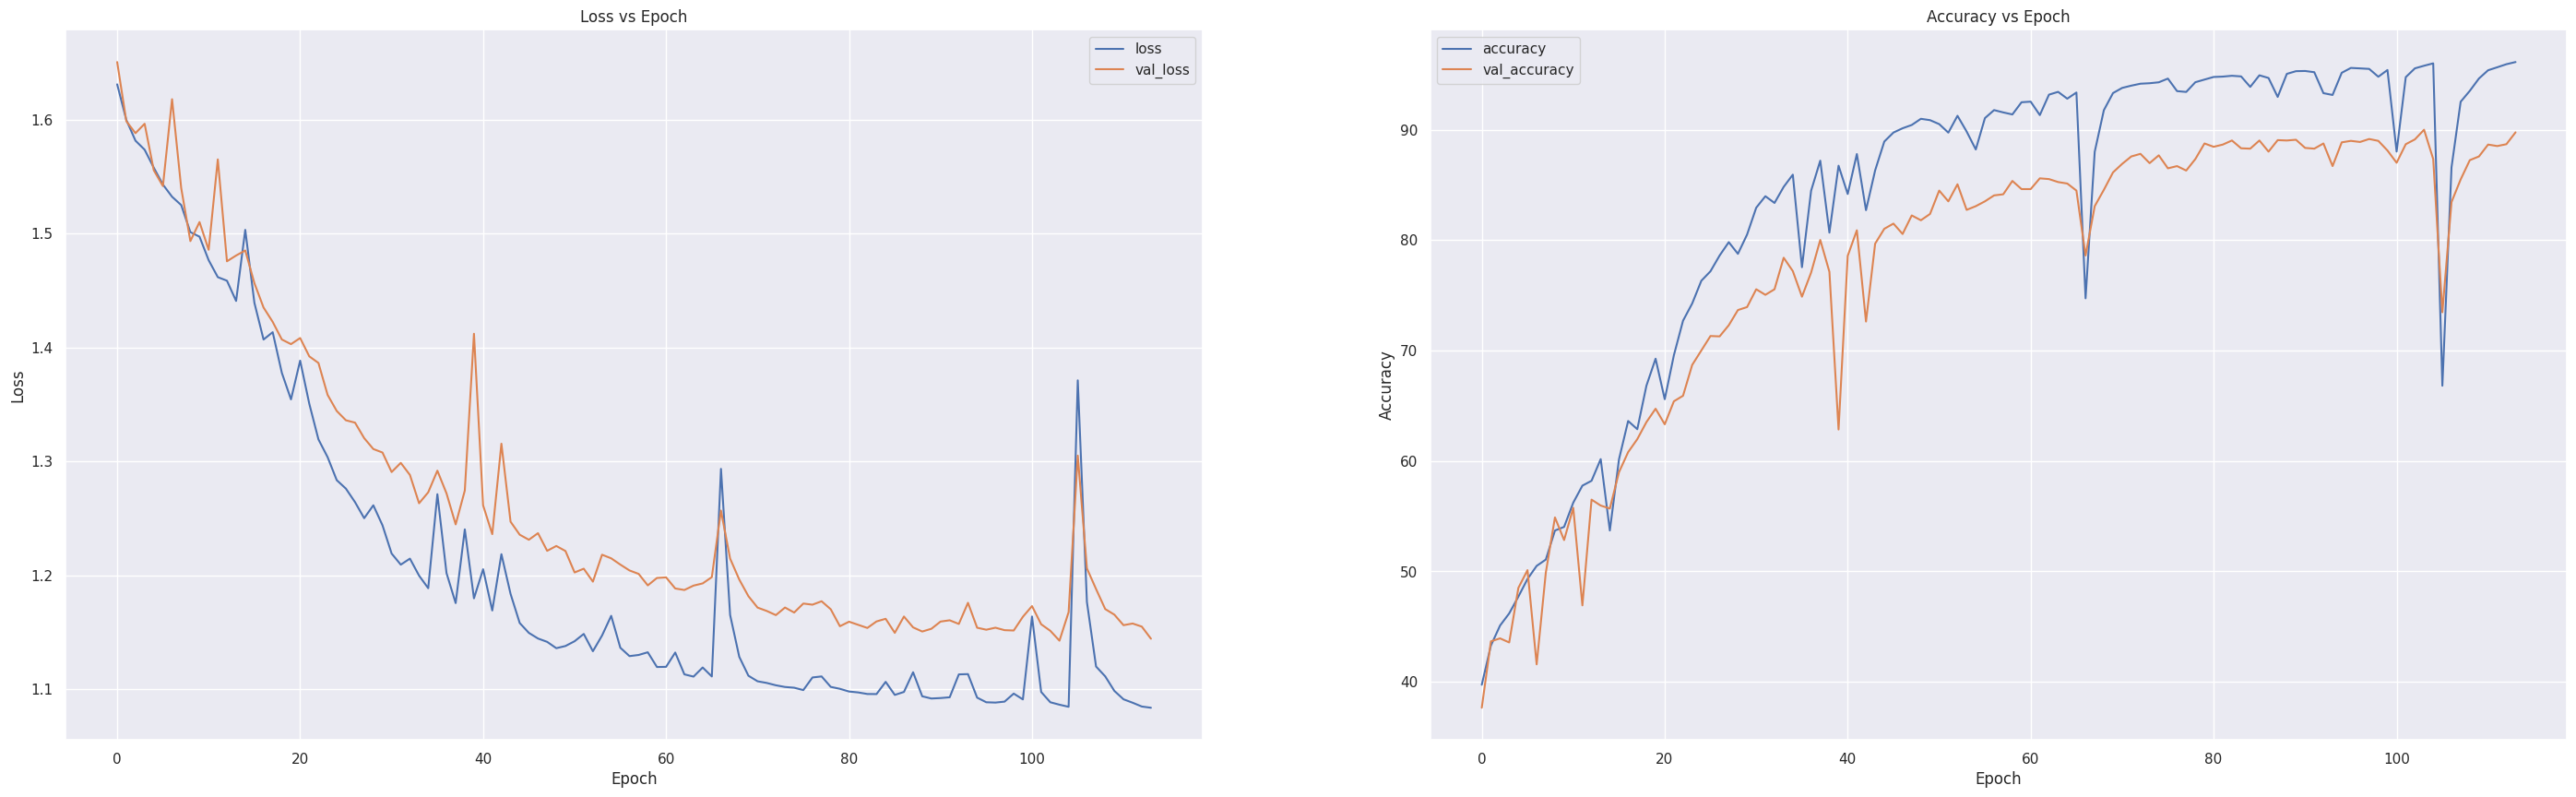

In [ ]:
# Альтернативная визуализация с matplotlib
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(history['loss'], label='loss')
ax1.plot(history['val_loss'], label='val_loss')
ax1.legend()
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss vs Epoch')
ax1.grid(True)

ax2.plot(history['accuracy'], label='accuracy')
ax2.plot(history['val_accuracy'], label='val_accuracy')
ax2.legend()
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Epoch')
ax2.grid(True)

fig.set_figheight(10)
fig.set_figwidth(35)
plt.show()

## 4.4 Make and Evaluate New Predictions Using Our Testing Data


In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Предсказание
model.eval()
test_loss = 0.0
correct = 0
total = 0
y_pred = []
y_check = []
with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs.squeeze(-1).unsqueeze(1))
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            y_pred.append(predicted.cpu())
            y_check.append(labels.cpu())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

test_loss /= len(valid_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 73.0594, Test Accuracy: 88.88%


In [ ]:
# y_pred stores the probabilities for each emotion. The highest probability corresponds to the predicted emotion.
print(y_pred[0])
print(y_check[0])


tensor([1])
tensor([5])


In [ ]:
# Calculate our accuracy score.
accuracy = accuracy_score(y_check, y_pred)

# Calculate our precision score.
precision = precision_score(y_check, y_pred, average = 'micro')

# Calculate our recall score.
recall = recall_score(y_check, y_pred, average = 'micro')

# Calculate our f1-score.
f1 = f1_score(y_check, y_pred, average = 'micro')

# Print each of our scores to inspect performance.
print('Accuracy Score: %f' % (accuracy * 100), '%', sep = '')
print('Precision Score: %f' % (precision * 100), '%', sep = '')
print('Recall Score: %f' % (recall * 100), '%', sep = '')
print('F1 Score: %f' % (f1 * 100), '%', sep = '')


Accuracy Score: 88.881424%
Precision Score: 88.881424%
Recall Score: 88.881424%
F1 Score: 88.881424%


## 4.5 Confusion Matrix


[[[2395   53]
  [  53  476]]

 [[2423   52]
  [  71  431]]

 [[2403   56]
  [  73  445]]

 [[2385   62]
  [  59  471]]

 [[2527   42]
  [  36  372]]

 [[2421   66]
  [  39  451]]] 



         angry  disgust  fear  happy  neutral  sad
angry      476        8    14     21        6    4
disgust     18      431    13     14        7   19
fear        14       10   445     17       13   19
happy       16       11    16    471        8    8
neutral      3        3     7      7      372   16
sad          2       20     6      3        8  451 





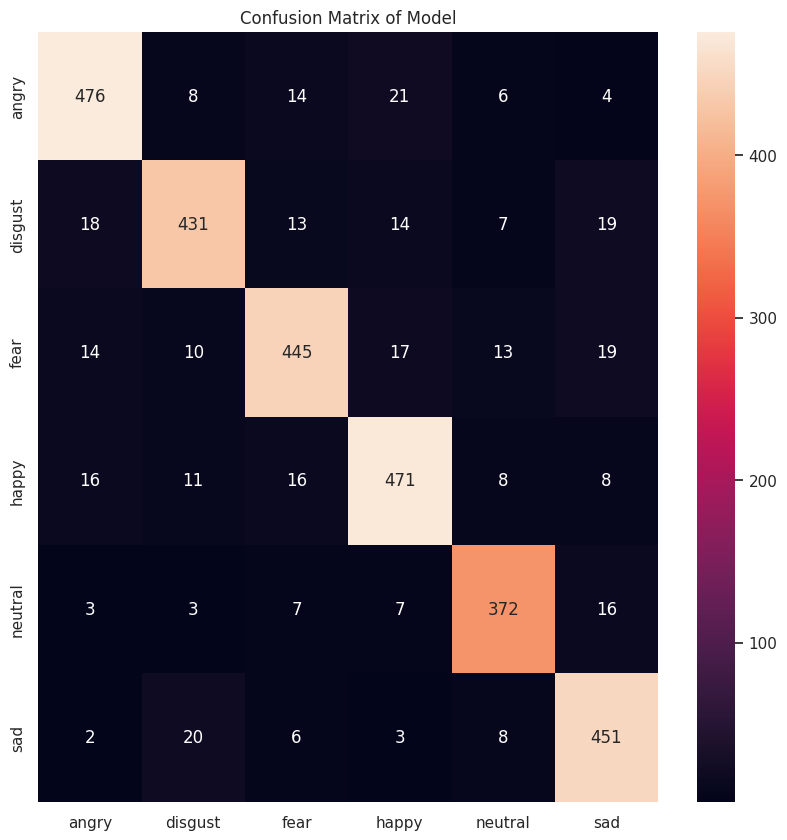

In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.title('Confusion Matrix of Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')

cm = multilabel_confusion_matrix(y_check, y_pred)
print(cm, '\n\n\n')

model_matrix = confusion_matrix(y_check, y_pred)
cm = pd.DataFrame(model_matrix,
                  index = [i for i in emotions_classes],
                  columns = [i for i in emotions_classes]
                 )


ax = sns.heatmap(cm,
                 annot = True,
                 fmt = 'd',cbar=True)

print(cm, '\n\n\n')

plt.show()


## 4.6 Classification Report


In [ ]:
print('Model Classification Report\n', classification_report(y_check, y_pred, target_names = emotions_classes))


Model Classification Report
               precision    recall  f1-score   support

       angry       0.90      0.90      0.90       529
     disgust       0.89      0.86      0.88       502
        fear       0.89      0.86      0.87       518
       happy       0.88      0.89      0.89       530
     neutral       0.90      0.91      0.91       408
         sad       0.87      0.92      0.90       490

    accuracy                           0.89      2977
   macro avg       0.89      0.89      0.89      2977
weighted avg       0.89      0.89      0.89      2977



## 4.7 Predict an Unknown Audion File (outside from the four used data sets) In a .wav Format


In [466]:
import torch
import numpy as np
import librosa
import torch.nn.functional as F
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler
import IPython.display as ipd

# Настройка устройства (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Загрузка обученной модели
model_path = 'speech_model.pth'
model = CNN1D(num_classes=len(emotions_classes))  # Создание модели с нужным числом классов
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# Предполагается, что у вас есть обученный StandardScaler
scaler_filename = 'standard_scaler.save'
standard_scaler = joblib.load(scaler_filename)

# Функция для увеличения размерности массива до требуемого размера (добавляем нули)
def increase_ndarray_size(features, target_length=2376):
    current_length = features.shape[1]

    if current_length < target_length:
        # Создаем новый массив с добавленными нулями для соответствия target_length
        pad_width = target_length - current_length
        features = np.pad(features, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)

    return features

# Функция для предсказания на основе аудиофайла
def predict(file_path):
    # Извлечение признаков из аудиофайла
    features = get_features(file_path)
    
    # Проверяем размер фичей и увеличиваем размерность при необходимости
    features = increase_ndarray_size(features)
    print('features_test.shape = ', features.shape)
    
    # Масштабирование признаков
    features = standard_scaler.transform(features)  # Преобразуем в массив с одной строкой для масштабирования
    
    # Преобразование в тензор и перенос на устройство
    features_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(1).to(device)
    
    # Предсказание
    with torch.no_grad():
        outputs = model(features_tensor)
        probabilities = F.softmax(outputs, dim=1)  # Получаем вероятности
        y_pred = torch.argmax(probabilities, dim=1)  # Находим индекс максимальной вероятности

    # Перенос предсказаний на CPU и преобразование в NumPy
    y_pred = y_pred.cpu().numpy()
    
    # Вывод предсказанной эмоции
    try:
        print(y_pred)
        predicted_emotion = emotions_classes[mode(y_pred).mode]
        predicted_prob = mode(probabilities.cpu().numpy()).mode
    except:
        predicted_emotion = emotions_classes[y_pred[0]]
        predicted_prob = probabilities.cpu().numpy()[0]
    print(f'\nModel predicted emotion: {predicted_emotion}, prob: {predicted_prob}')
    print('************************************************')

    # Проигрывание аудио
    ipd.display(ipd.Audio(file_path))
    print('Duration:', librosa.get_duration(path=file_path))

# Основная часть выполнения инференса
sound_file_path = './CREMA-D/AudioWAV/1001_DFA_FEA_XX.wav'  # Путь к файлу аудио
predict(sound_file_path)


Using device: cuda
features_test.shape =  (4, 2376)
[2 2 2 2]

Model predicted emotion: fear, prob: [0.12956251 0.12956251 0.3521874  0.12956251 0.12956251 0.12956251]
************************************************


Duration: 2.1688125


## 4.9 Fast/Automatic Way to Split Audio Files Into Chunks of 2.5 Seconds Audio Files (in ***4.8*** it was done manually which is not ideal for large audio file splitting)


> ## 4.9.1 Remove the Silence Gaps to Do Not Interfere With the Prediction of the Model


In [ ]:
file = '../input/randomaudio/angry_disgust_fear_happy_sad.wav'
sound = AudioSegment.from_wav(file)
audio_chunks = split_on_silence(sound,
                                min_silence_len = 100,
                                silence_thresh = -45,
                                keep_silence = 50)

# Putting the file back together.
combined = AudioSegment.empty()
for chunk in audio_chunks:
    combined += chunk
    combined.export('audio_no_silence_gap.wav', format = 'wav')

IPython.display.display(IPython.display.Audio(data = './audio_no_silence_gap.wav'))


> ### 4.9.2 Split Automatically Based on Time of 2.5 Seconds (more accurate method as model was trained on audio files that were about 2.5 seconds)


In [463]:
start = 0
end = librosa.get_duration(path = './audio_no_silence_gap.wav') * 1000 # pydub works in milliseconds. liborsa works in seconds.

# Replace number 2.5 with the number of desired seconds that each audio file will be after the splitting.
# Model was train on about 2.5 seconds audio recordings.
time_change = 2.5 * 1000 # In milliseconds.
count = 0
for i in np.arange(start, end, time_change):
    if i != 0 :
        tmp = sound[i - 500:i + time_change] # Decrease by 500 milliseconds(0.5 seconds) to get a sense of the previous audio split.
    else:
        tmp = sound[i:i + time_change]
    tmp.export('audio_split_' + str(count) + '.wav', format = 'wav')
    print('Exporting file:', 'audio_split_' + str(count) + '.wav')
    count += 1


FileNotFoundError: [Errno 2] No such file or directory: './audio_no_silence_gap.wav'

In [ ]:
# # Split Automatically Based On Silence Detected Between Sounds (Less Accurate Method Because It Produces Audio Files With Less Than Or Greater Than 2.5 Seconds Duration)

# # Reading from audio .wav file.
# file = '../input/randomaudio/angry_disgust_fear_happy_sad.wav'
# song = AudioSegment.from_wav(file)
# IPython.display.display(IPython.display.Audio(data = file))

# # Spliting audio files.
# audio_splits = split_on_silence(audio_segment = song, min_silence_len = 900, silence_thresh = -40)
# count = 0
# # Loop is used to iterate over the output list.
# for i, split in enumerate(audio_chunks):
#     split.export('audio_split_' + str(count) + '.wav', format = 'wav')
#     print('Exporting file:', 'audio_split_' + str(count) + '.wav')
#     count += 1
    

In [ ]:
# # Delete unecessary output files in /kaggle/working

# for dirname, _, filenames in os.walk('/kaggle/working/'):
#     for filename in filenames:
#         if 'state.db' not in filename:
#             os.remove(filename)
